In [1]:
import pandas as pd

import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

from haversine import haversine, Unit
from sklearn.impute import KNNImputer
import math

import warnings
warnings.filterwarnings("ignore")

In [2]:
### carga datos de dataset en dataframe
file_path= 'uber_fares.csv'

df = pd.read_csv(file_path)

In [3]:
### visualizacion de algunos datos
df.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


#### Contexto  
El proyecto trata sobre **Uber Inc.**, la compañía de taxis más grande del mundo. En este trabajo, nuestro objetivo es **predecir la tarifa de futuros viajes**.  

Uber brinda servicio a millones de clientes cada día, por lo que gestionar adecuadamente sus datos es clave para desarrollar nuevas estrategias de negocio y obtener mejores resultados.  

### Variables del conjunto de datos  

**Variables explicativas:**  
- **key**: identificador único de cada viaje.  
- **pickup_datetime**: fecha y hora en que se inició el viaje.  
- **passenger_count**: cantidad de pasajeros en el vehículo (dato ingresado por el conductor).  
- **pickup_longitude**: longitud del punto de inicio del viaje.  
- **pickup_latitude**: latitud del punto de inicio del viaje.  
- **dropoff_longitude**: longitud del punto de destino.  
- **dropoff_latitude**: latitud del punto de destino.  

**Variable objetivo (target):**  
- **fare_amount**: costo del viaje en dólares.  

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [5]:
df_limpio = df.copy()

# Dividir datos de entrenamiento y testeo

In [6]:
x = df_limpio.drop('fare_amount', axis=1)
y = df_limpio['fare_amount']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Feature Engineering

In [7]:
# Límites geográficos de Nueva York
NY_COORDENADAS = {
    'min_lat': 40.4774,
    'max_lat': 40.9176,
    'min_lon': -74.2591,
    'max_lon': -73.7004
}

## Filtro Geografico
Tomamos el criterio de analizar los viajes que se realizaron dentro de las coordenadas de Nueva York, y tomar como outliers los que se realizaron fuera de esa ubicacion.

In [8]:
# Filtramos los valores por fuera de las coordenadas de NY y completamos con nan los que están fuera
lat_cols = ['pickup_latitude', 'dropoff_latitude']
lon_cols = ['pickup_longitude', 'dropoff_longitude']

# En X_train
for col in lat_cols:
      mask = ~X_train[col].between(NY_COORDENADAS['min_lat'], NY_COORDENADAS['max_lat'])  # máscara para los valores que NO están entre las coordenadas
      X_train.loc[mask, col] = np.nan


for col in lon_cols:
      mask = ~X_train[col].between(NY_COORDENADAS['min_lon'], NY_COORDENADAS['max_lon']) # máscara para los valores que NO están entre las coordenadas
      X_train.loc[mask, col] = np.nan

# En X_test
for col in lat_cols:
      mask = ~X_test[col].between(NY_COORDENADAS['min_lat'], NY_COORDENADAS['max_lat'])  # máscara para los valores que NO están entre las coordenadas
      X_test.loc[mask, col] = np.nan

for col in lon_cols:
      mask = ~X_test[col].between(NY_COORDENADAS['min_lon'], NY_COORDENADAS['max_lon'])  # máscara para los valores que NO están entre las coordenadas
      X_test.loc[mask, col] = np.nan


In [9]:
# Coordenadas de Nueva York, dentro del rango y las completadas con NaN. Dan 160.000 de X_train. Correcto
print(sum(X_train['pickup_latitude'].between(NY_COORDENADAS['min_lat'], NY_COORDENADAS['max_lat'])))
print(sum(X_train['dropoff_latitude'].between(NY_COORDENADAS['min_lat'], NY_COORDENADAS['max_lat'])))
print(sum(X_train['dropoff_longitude'].between(NY_COORDENADAS['min_lon'], NY_COORDENADAS['max_lon'])))
print(sum(X_train['pickup_longitude'].between(NY_COORDENADAS['min_lon'], NY_COORDENADAS['max_lon'])) + sum(X_train['pickup_longitude'].isna()))
print(sum(X_train['dropoff_longitude'].isna()))
print(sum(X_train['pickup_longitude'].isna()))

156738
156726
156711
160000
3289
3284


In [10]:
# Comprobamos la cantidad de observaciones con longitud y latitud = 0
print(sum(X_train['pickup_latitude'] == 0))
print(sum(X_train['pickup_longitude'] == 0))
print(sum(X_train['dropoff_latitude'] == 0))
print(sum(X_train['dropoff_longitude'] == 0))
print(sum((X_train['pickup_longitude'] == 0)& (X_train['dropoff_latitude'] == 0)& (X_train['dropoff_longitude'] == 0) & (X_train['pickup_latitude'] == 0)))

print(sum(y_train == 0))

0
0
0
0
0
5


## Valores faltantes
Al principio decidimos utilizar el escalado robusto, pero los resultados obtenidos para el modelo eran muy pobres (menos de 8%).

Creditos al profe Ivan que nos sugirio usar el escalado estandar.

In [11]:
# Copiamos el df antes de tocar para luego comparar las distribuciones
X_train_antes_imputacion = X_train.copy()

In [12]:
# ESCALADO STANDARD

##### X_train #####
scaler = StandardScaler()
cols_a_escalar = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']

# Identificamos las filas sin NaN
filas_sin_nan = ~X_train[cols_a_escalar].isna().any(axis=1)
df_sin_nan = X_train.loc[filas_sin_nan, cols_a_escalar]

# Escalamos sólo las filas sin NaN
df_sin_nan_escalado_array = scaler.fit_transform(df_sin_nan)

# Creamos un nuevo DataFrame con los datos escalados, manteniendo el índice original
columnas_escaladas = [col + '_escalada' for col in cols_a_escalar]
df_sin_nan_escalado = pd.DataFrame(df_sin_nan_escalado_array, columns=columnas_escaladas, index=df_sin_nan.index)

# Unimos las nuevas columnas escaladas al df X_train original
X_train[columnas_escaladas] = np.nan

# Rellenamos las columnas nuevas con los valores escalados
X_train.loc[df_sin_nan_escalado.index, columnas_escaladas] = df_sin_nan_escalado.values


##### Lo mismo con X_test #####
filas_sin_nan = ~X_test[cols_a_escalar].isna().any(axis=1)
df_sin_nan = X_test.loc[filas_sin_nan, cols_a_escalar]

df_sin_nan_escalado_array = scaler.transform(df_sin_nan)

columnas_escaladas = [col + '_escalada' for col in cols_a_escalar]
df_sin_nan_escalado = pd.DataFrame(df_sin_nan_escalado_array, columns=columnas_escaladas, index=df_sin_nan.index)

X_test[columnas_escaladas] = np.nan

X_test.loc[df_sin_nan_escalado.index, columnas_escaladas] = df_sin_nan_escalado.values

## Imputacion

In [13]:
# Imputamos las COORDENADAS con KNN
imputer = KNNImputer(n_neighbors=5)

cols = ['pickup_longitude_escalada','pickup_latitude_escalada','dropoff_latitude_escalada','dropoff_longitude_escalada']

X_train[cols] = imputer.fit_transform(X_train[cols])
X_test[cols] = imputer.transform(X_test[cols])

In [14]:
# DESESCALADO
col_escaladas = ['pickup_longitude_escalada', 'pickup_latitude_escalada', 'dropoff_longitude_escalada', 'dropoff_latitude_escalada', 'passenger_count_escalada']


##### X_train #####
# Desescalamos los datos de TODAS las columnas
datos_desescalados_array = scaler.inverse_transform(X_train[col_escaladas].values)

# Creamos una lista con los nombres de las columnas nuevas con el sufijo '_desescalada'
col_desescaladas = [col.replace('_escalada', '_desescalada') for col in col_escaladas]

# Asignamos los valores desescalados a las columnas nuevas en X_train
X_train[col_desescaladas] = datos_desescalados_array


##### Lo mismo con X_test #####
datos_desescalados_array = scaler.inverse_transform(X_test[col_escaladas].values)

col_desescaladas = [col.replace('_escalada', '_desescalada') for col in col_escaladas]

X_test[col_desescaladas] = datos_desescalados_array

## Comparacion de las distribuciones ANTES y DESPUES de imputar

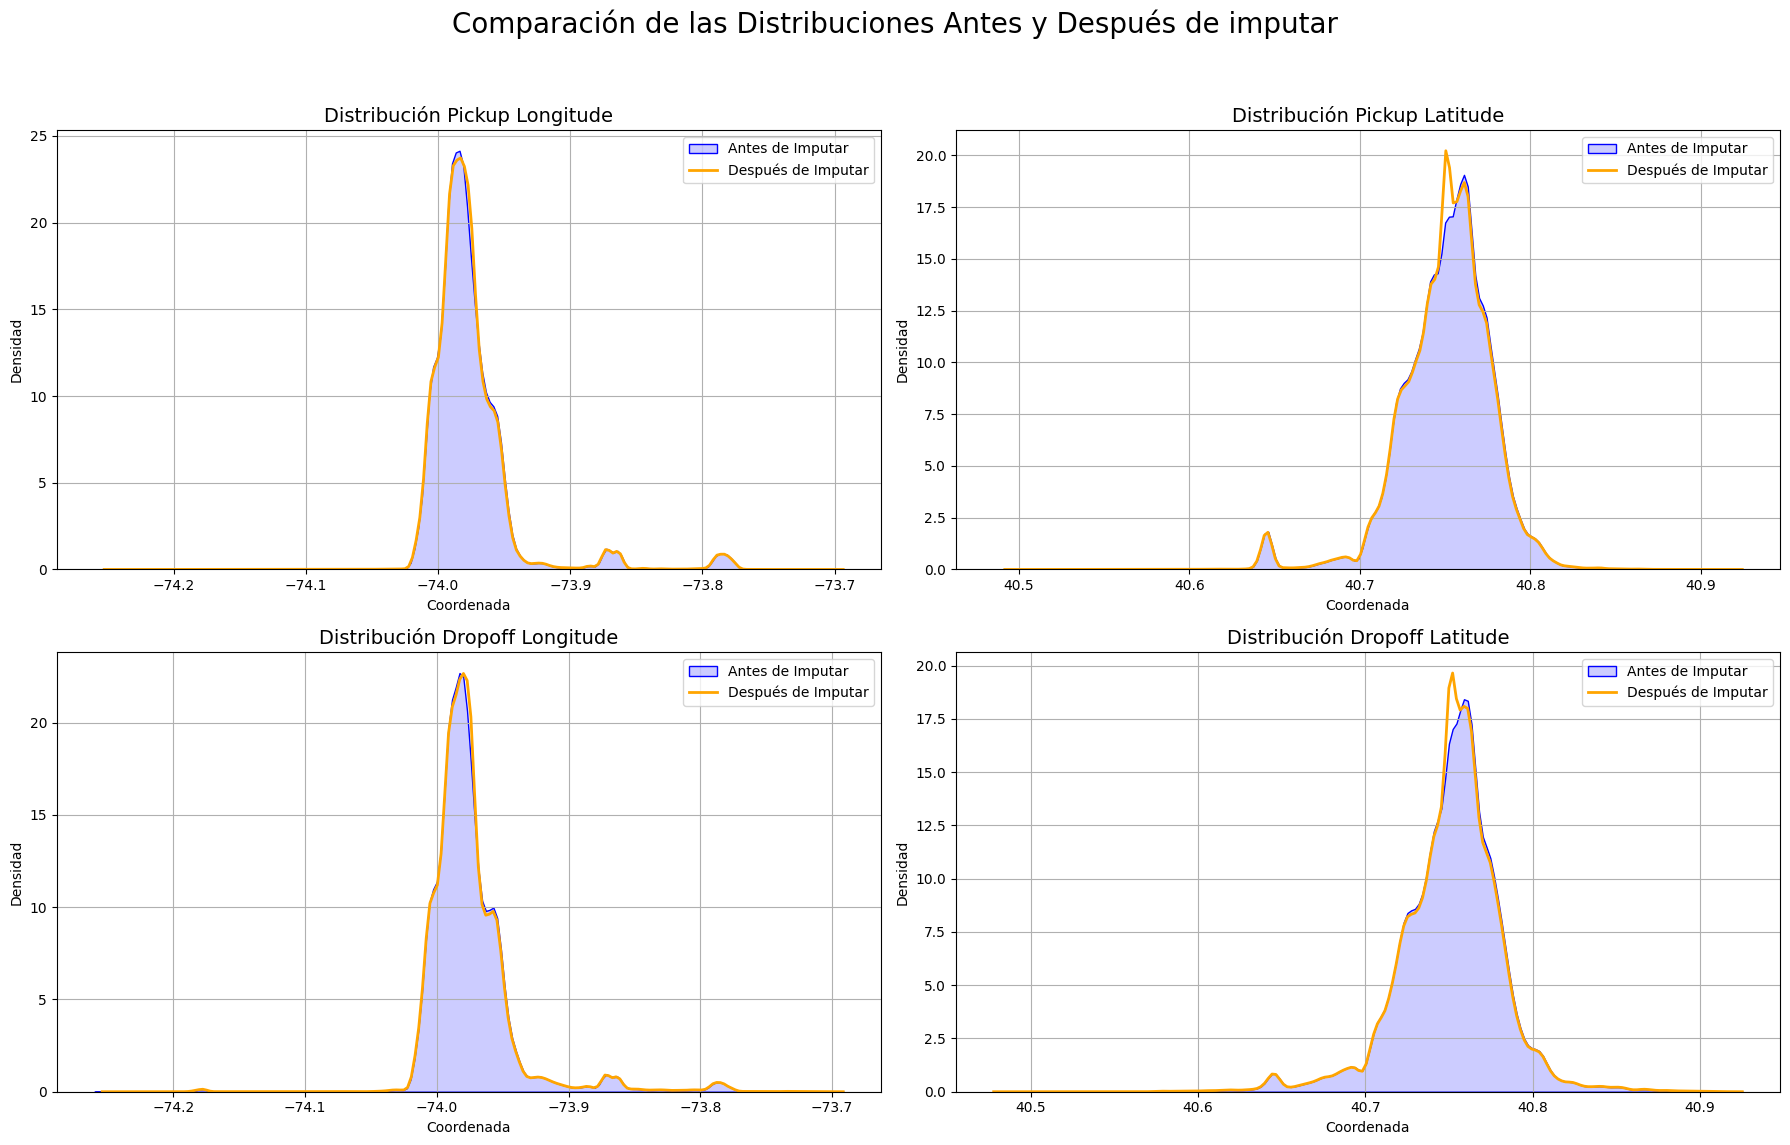

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Comparación de las Distribuciones Antes y Después de imputar', fontsize=20)

columnas_y_titulos = [
    ('pickup_longitude', 'pickup_longitude_desescalada', 'Distribución Pickup Longitude'),
    ('pickup_latitude', 'pickup_latitude_desescalada', 'Distribución Pickup Latitude'),
    ('dropoff_longitude', 'dropoff_longitude_desescalada', 'Distribución Dropoff Longitude'),
    ('dropoff_latitude', 'dropoff_latitude_desescalada', 'Distribución Dropoff Latitude')
]

axes = axes.flatten()

for i, (col_antes, col_despues, titulo) in enumerate(columnas_y_titulos):
    # Distribución ANTES
    sns.kdeplot(
        data=X_train_antes_imputacion[col_antes].dropna(),
        ax=axes[i],
        label='Antes de Imputar',
        color='blue',
        fill=True,
        alpha=0.2
    )

    # Distribución DESPUÉS
    sns.kdeplot(
        data=X_train[col_despues],
        ax=axes[i],
        label='Después de Imputar',
        color='orange',
        linewidth=2
    )

    axes[i].set_title(titulo, fontsize=14)
    axes[i].set_xlabel('Coordenada')
    axes[i].set_ylabel('Densidad')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Calculo de las distancias recorridas en km

In [16]:
##### X_train #####
X_train['distancia_km'] = X_train.apply(lambda row: haversine(
  (row['pickup_latitude_desescalada'], row['pickup_longitude_desescalada']),
  (row['dropoff_latitude_desescalada'], row['dropoff_longitude_desescalada'])
), axis=1)

X_train['distancia_km'].describe()

count    160000.000000
mean          3.237380
std           3.545887
min           0.000000
25%           1.206936
50%           2.111059
75%           3.841573
max          35.341909
Name: distancia_km, dtype: float64

In [17]:
##### X_test #####
X_test['distancia_km'] = X_test.apply(lambda row: haversine(
    (row['pickup_latitude_desescalada'], row['pickup_longitude_desescalada']),
    (row['dropoff_latitude_desescalada'], row['dropoff_longitude_desescalada'])
), axis=1)

## Tratamiento de las fechas
### Dia de la semana

In [18]:
## Primero convertimos a datetime y luego conseguimos el dia de la semana (numerico)

##### X_train #####
X_train['day_week_num'] = pd.to_datetime(X_train['date'], utc=True)
X_train['day_week_num'] = X_train['day_week_num'].dt.dayofweek
X_train['day_week_num']

##### X_test #####
X_test['day_week_num'] = pd.to_datetime(X_test['date'], utc=True)
X_test['day_week_num'] = X_test['day_week_num'].dt.dayofweek

# Despues usamos ese numero que representa el dia de la semana para la Codificacion Ciclica de los dias
def circular_encoding(X_train, column, n_categorias):
    sin_col = f"{column}_sin"
    cos_col = f"{column}_cos"
    X_train[sin_col] = np.sin((2 * np.pi * (X_train[column]))/ n_categorias)
    X_train[cos_col] = np.cos((2 * np.pi * (X_train[column])) / n_categorias)
    return X_train

X_train = circular_encoding(X_train, 'day_week_num', 7)

X_test = circular_encoding(X_test, 'day_week_num', 7)

In [19]:
print(X_train['day_week_num_sin'])

153248    0.433884
67802     0.974928
148889   -0.781831
103093   -0.974928
104681   -0.781831
            ...   
119879    0.433884
103694   -0.781831
131932   -0.974928
146867    0.781831
121958   -0.974928
Name: day_week_num_sin, Length: 160000, dtype: float64


In [20]:
##### X_train #####
X_train['fecha_hora'] = pd.to_datetime(X_train['date'].str.replace(' UTC', ''), utc=True) #convertirmos a datetime

X_train['hora'] = X_train['fecha_hora'].dt.hour # extraemos la hora de la fecha general

etiquetas = ['Madrugada', 'Mañana', 'Tarde', 'Noche']

bins = [0, 6, 12, 18, 24]

X_train['period_of_the_day'] = pd.cut(X_train['hora'], bins=bins, labels=etiquetas, right=False, include_lowest=True) # generamos una columna nueva con las variables categóricas

X_train['period_of_the_day']

##### X_test #####
X_test['fecha_hora'] = pd.to_datetime(X_test['date'].str.replace(' UTC', ''), utc=True)

X_test['hora'] = X_test['fecha_hora'].dt.hour

etiquetas = ['Madrugada', 'Mañana', 'Tarde', 'Noche']
bins = [0, 6, 12, 18, 24]

X_test['period_of_the_day'] = pd.cut(X_test['hora'], bins=bins, labels=etiquetas, right=False, include_lowest=True)

In [21]:
# Circulamos enconding para el momento del día
X_train = circular_encoding(X_train, 'hora', 24)

X_test = circular_encoding(X_test, 'hora', 24)

X_train['hora_cos']

153248    0.707107
67802     0.866025
148889   -0.500000
103093    0.965926
104681   -0.965926
            ...   
119879   -0.258819
103694    0.258819
131932   -0.965926
146867    0.258819
121958   -0.707107
Name: hora_cos, Length: 160000, dtype: float64

In [ ]:
# Cantidad de pasajeros mayores a 10
##### X_train #####
print(f"Cantidad de pasajeros mayores a 10 ANTES del filtro: {(X_train['passenger_count'] > 10).sum()}")

# Creamos la máscara para pasajeros <= 10
valid_passengers_mask = X_train['passenger_count'] <= 10

# Aplicamos el filtro a X_train
X_train = X_train[valid_passengers_mask]

# Aplicamos el mismo filtro a y_train usando la misma mascara
y_train = y_train[valid_passengers_mask]


##### X_train #####
# Gastos menores a 0 dolares y_train
print(f"\nCantidad de gastos menores o iguales a 0 ANTES del filtro: {(y_train <= 0).sum()}")

# Creamos la máscara para gastos mayores o iguales a 0
valid_fare_amount_mask = y_train > 0

# Aplicamos el filtro a y_train
y_train = y_train[valid_fare_amount_mask]

# Aplicamos el mismo filtro a X_train usando la misma mascara
X_train = X_train[valid_fare_amount_mask]

# x_test
valid_fare_amount_mask = y_test > 0
y_test = y_test[valid_fare_amount_mask]
X_test = X_test[valid_fare_amount_mask]


Cantidad de pasajeros mayores a 10 ANTES del filtro: 1

Cantidad de gastos menores o iguales a 0 ANTES del filtro: 19


In [23]:
# Verificamos el tamanio de los conjuntos
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((159980, 27), (159980,), (39997, 27), (39997,))

## Distribuciones

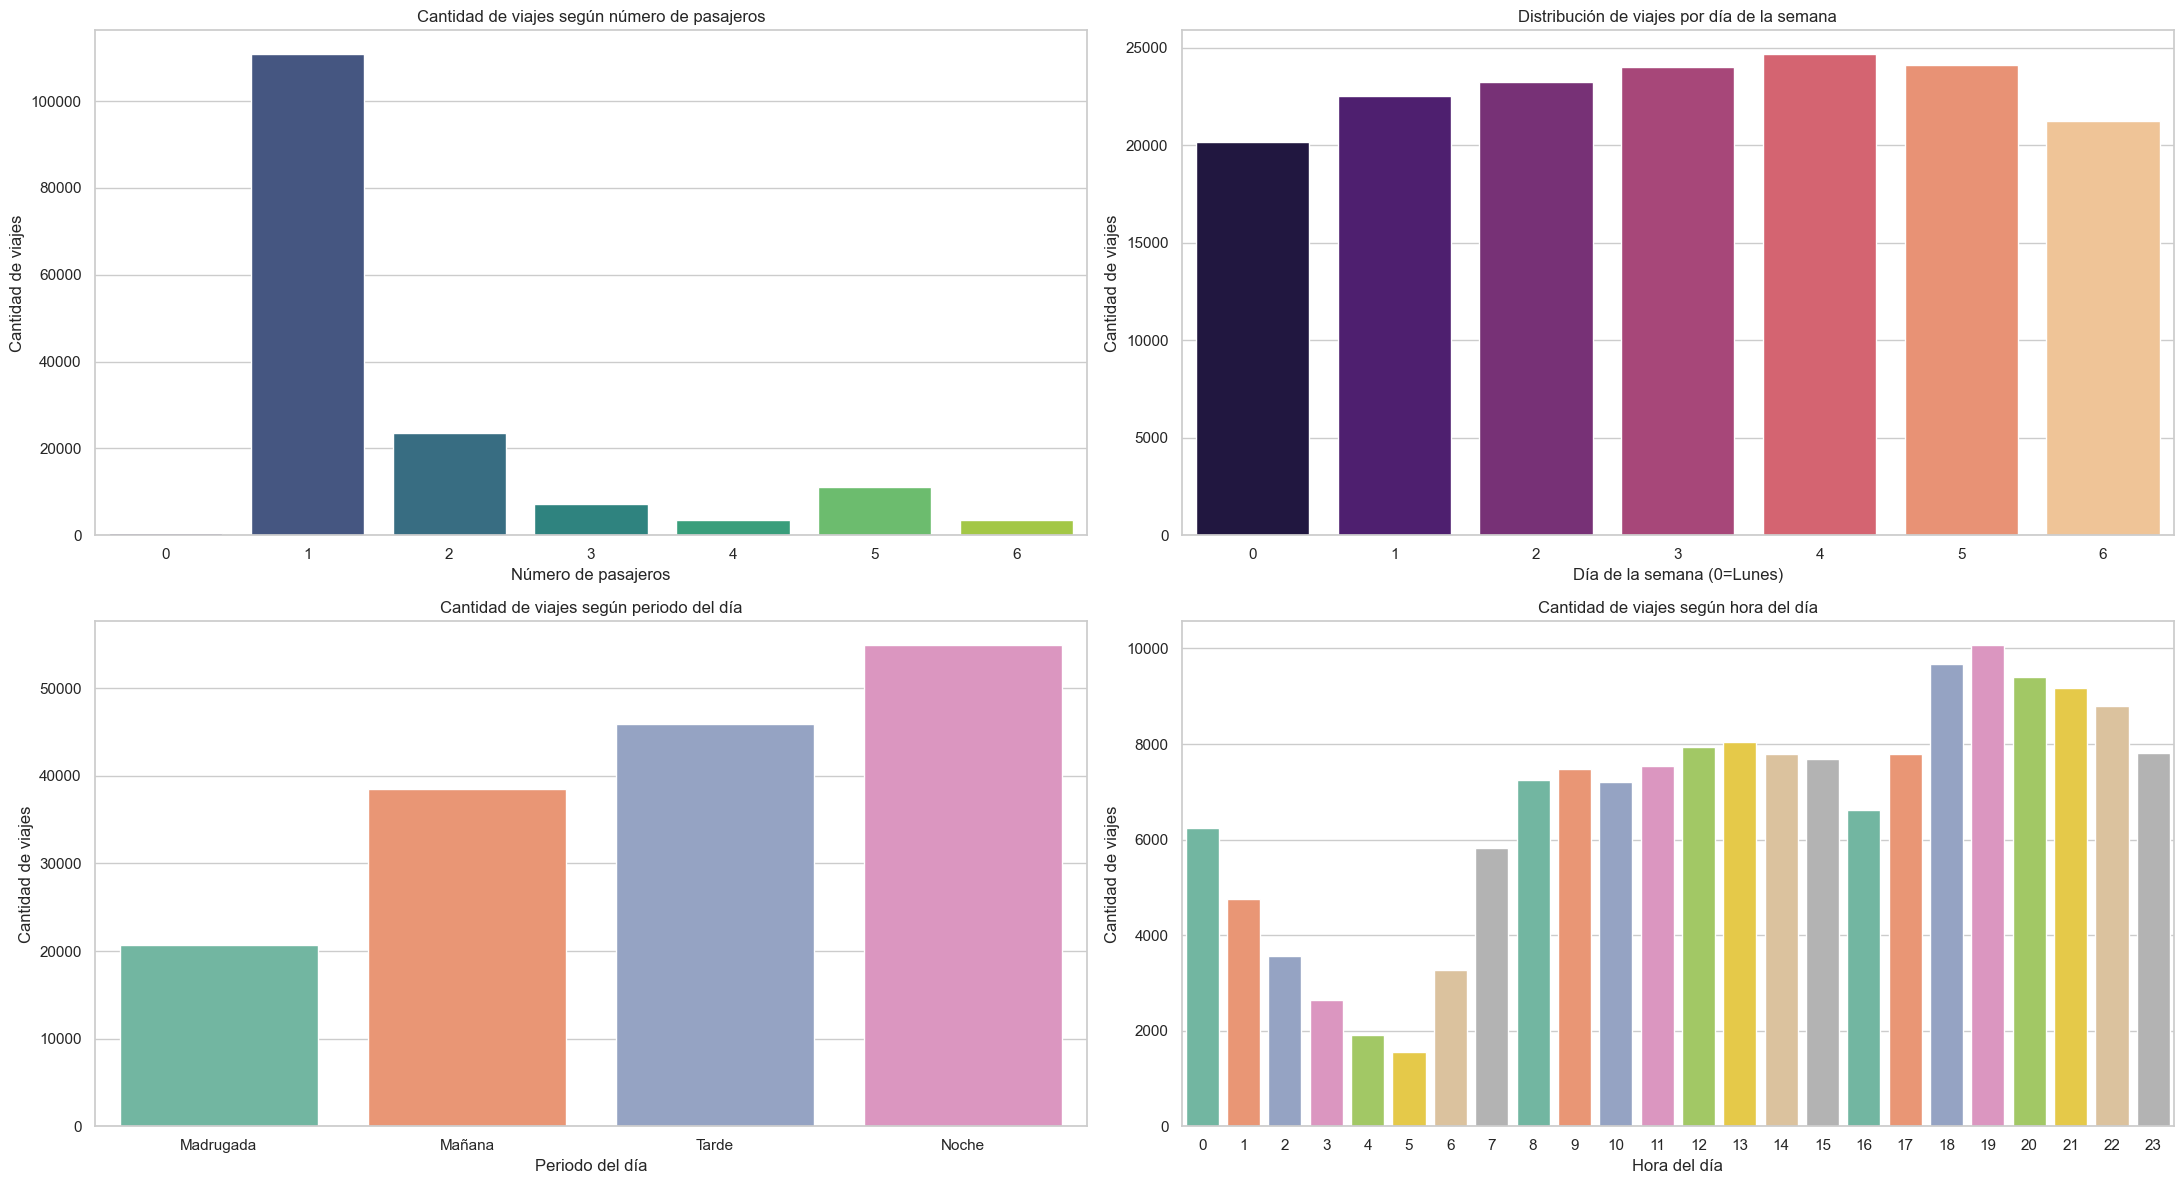

In [24]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(22, 12))

# Conteo de viajes por cantidad de pasajeros
sns.countplot(data=X_train, x="passenger_count", ax=axes[0,0], palette="viridis")
axes[0,0].set_title("Cantidad de viajes según número de pasajeros")
axes[0,0].set_xlabel("Número de pasajeros")
axes[0,0].set_ylabel("Cantidad de viajes")

# Conteo de viajes por día de la semana
order_days = [0, 1, 2, 3, 4, 5, 6]  # Lunes=0 ... Domingo=6
sns.countplot(data=X_train, x="day_week_num", order=order_days, ax=axes[0,1], palette="magma")
axes[0,1].set_title("Distribución de viajes por día de la semana")
axes[0,1].set_xlabel("Día de la semana (0=Lunes)")
axes[0,1].set_ylabel("Cantidad de viajes")

# Conteo de viajes por franja horaria del día
sns.countplot(
    data=X_train,
    x="period_of_the_day",
    order=["Madrugada", "Mañana", "Tarde", "Noche"],
    ax=axes[1,0],
    palette="Set2"
)
axes[1,0].set_title("Cantidad de viajes según periodo del día")
axes[1,0].set_xlabel("Periodo del día")
axes[1,0].set_ylabel("Cantidad de viajes")

# Conteo de viajes por franja horaria del día
sns.countplot(
    data=X_train,
    x="hora",
    ax=axes[1,1],
    palette="Set2"
)
axes[1,1].set_title("Cantidad de viajes según hora del día")
axes[1,1].set_xlabel("Hora del día")
axes[1,1].set_ylabel("Cantidad de viajes")


plt.tight_layout()
plt.show()

Obervamos que:
- La gran mayoria de los viajes fueron realizados con un unico pasajero.
- La mayor cantidad de viajes se realizan durante los ultimos 3 dias habiles, con pico el viernes.
- La cantidad de viajes asciente desde la madrugada (5am) hasta la noche, y vuelve a caer desde las 7pm hasta las 5am.

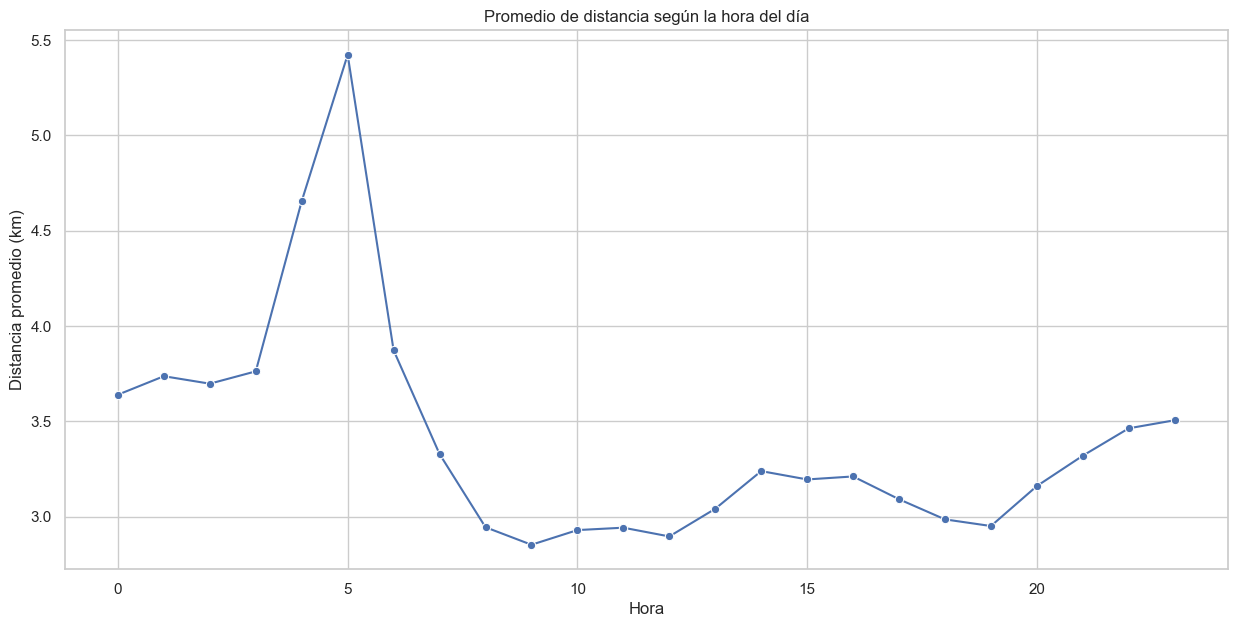

In [25]:
# Promedio de distancia según hora del día

plt.figure(figsize=(15,7))
sns.lineplot(data=X_train, x="hora", y="distancia_km", estimator="mean", ci=None, marker="o")
plt.title("Promedio de distancia según la hora del día")
plt.xlabel("Hora")
plt.ylabel("Distancia promedio (km)")
plt.show()


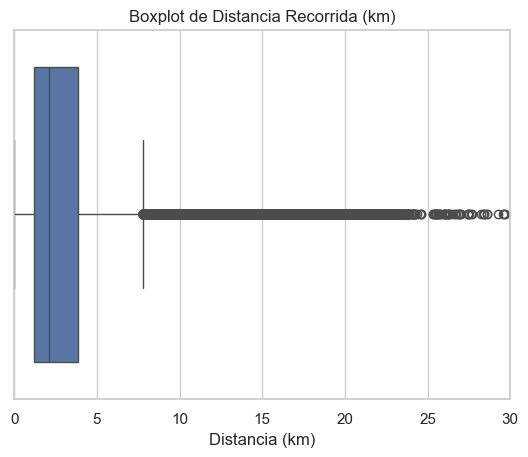

In [26]:
# Boxplot distancia
sns.boxplot(x=X_train['distancia_km'])
plt.title("Boxplot de Distancia Recorrida (km)")
plt.xlabel("Distancia (km)")
plt.xlim(0, 30)
plt.show()

In [27]:
X_train['distancia_km'].describe()

count    159980.000000
mean          3.237486
std           3.545644
min           0.000000
25%           1.207130
50%           2.111145
75%           3.841721
max          35.341909
Name: distancia_km, dtype: float64

Observamos que:
- Los viajes mas largos, en promedio, se realizan a las 5am, a pesar de ser el horario en el que menos viajes se realizan.
- La mayoria de los viajes tienen una distancia menor a 3.25km.

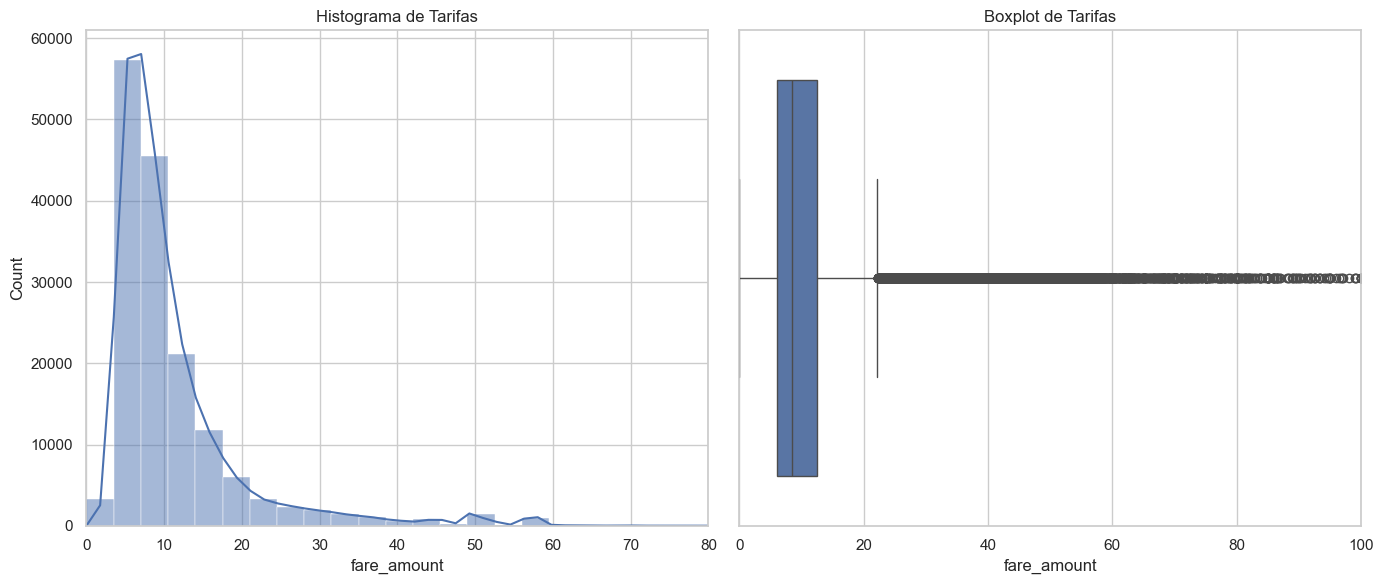

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma de tarifas
sns.histplot(y_train, bins=100, kde=True, ax=axes[0])
axes[0].set_xlim(0, 80)  # límitamos para ver mejor la zona central
axes[0].set_title("Histograma de Tarifas")

# Boxplot de tarifas
sns.boxplot(x=y_train, ax=axes[1])
axes[1].set_xlim(0, 100)
axes[1].set_title("Boxplot de Tarifas")

plt.tight_layout()
plt.show()

In [29]:
y_train.describe()

count    159980.000000
mean         11.354532
std           9.791008
min           0.010000
25%           6.000000
50%           8.500000
75%          12.500000
max         350.000000
Name: fare_amount, dtype: float64

- Se puede apreciar que la mayoria de los viajes son de los mas baratos, lo que se condice con los graficos anteriores, en el que predominan los viajes con distancias cortas.
- La distribucion es asimetrica a la derecha.

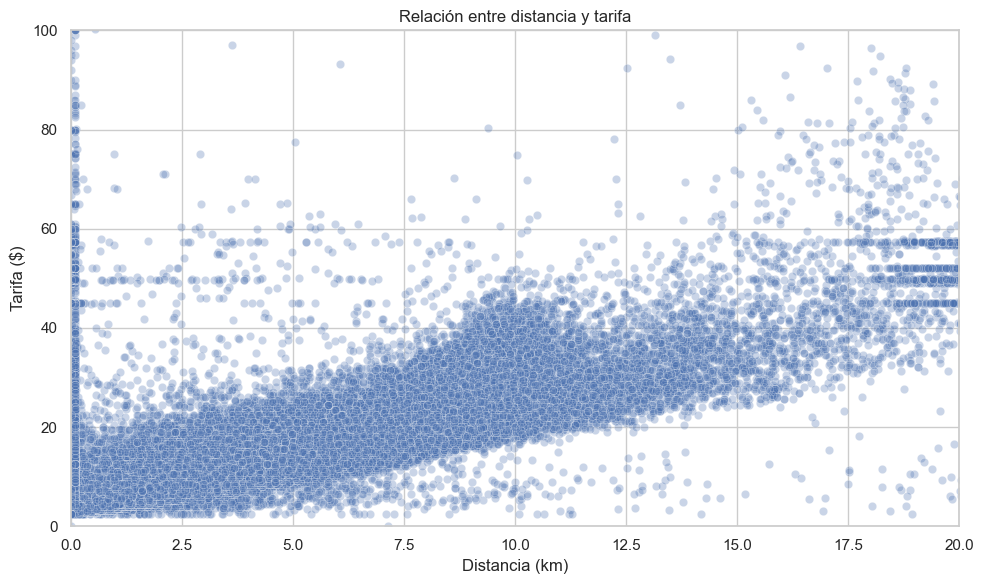

In [30]:
# Scatterplot entre distancia y tarifa
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train["distancia_km"], y=y_train, alpha=0.3)
plt.xlim(0, 20)   # Limitamos a 20 km para evitar outliers extremos
plt.ylim(0, 100)  # Limitamos a 100 dólares para evitar outliers extremos
plt.title("Relación entre distancia y tarifa")
plt.xlabel("Distancia (km)")
plt.ylabel("Tarifa ($)")
plt.tight_layout()
plt.show()

Vemos que hay outliers de viajes realizados con una tarifa muy alta y una distancia muy corta, verificamos la cantidad.

In [31]:
print(sum((y_train > 40) & (X_train['distancia_km'] < 0.5)))

486


In [32]:
# Manejamos estos outliers
condicion_excluir = (y_train > 20) & (X_train['distancia_km'] < 0.5)

mediana_menores_20 = y_train.loc[~condicion_excluir & (y_train < 20)].median()

condicion_imputar = (y_train > 20) & (X_train['distancia_km'] < 0.5)

y_train.loc[condicion_imputar] = mediana_menores_20

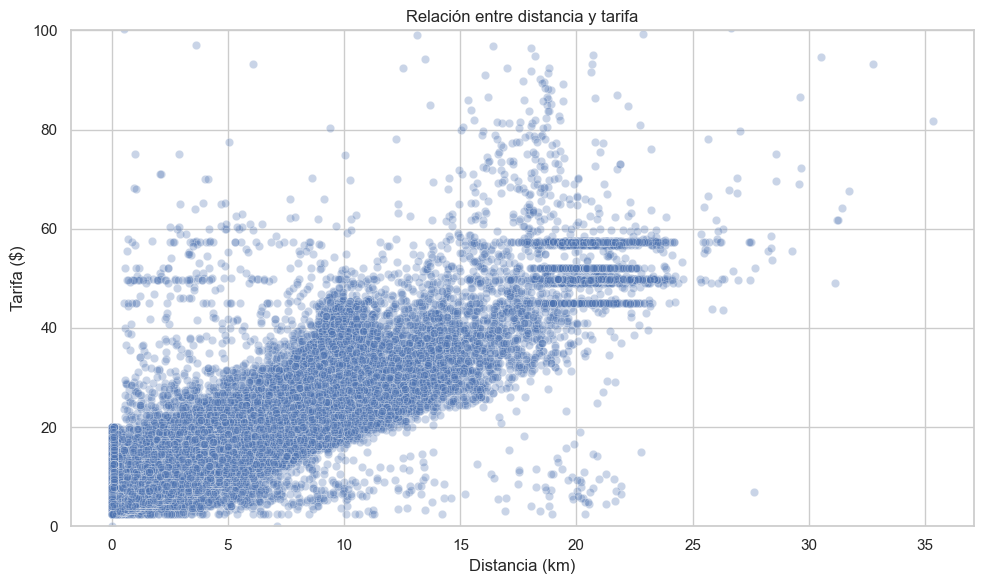

In [33]:
# Vemos como queda el grafico sin esos outliers
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train["distancia_km"], y=y_train, alpha=0.3)
plt.ylim(0, 100)
plt.title("Relación entre distancia y tarifa")
plt.xlabel("Distancia (km)")
plt.ylabel("Tarifa ($)")
plt.tight_layout()
plt.show()

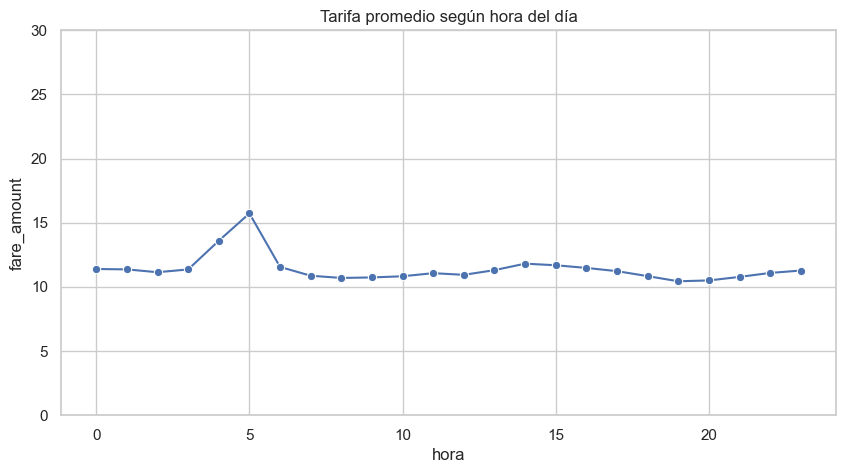

In [34]:
# Fare por hora del día

plt.figure(figsize=(10,5))
sns.lineplot(x=X_train["hora"], y=y_train, estimator="mean", errorbar=None, marker="o")
plt.ylim(0, 30)
plt.title("Tarifa promedio según hora del día")
plt.show()

Los viajes mas largos son los que se realizan a las 5, y tambien los mas caros.

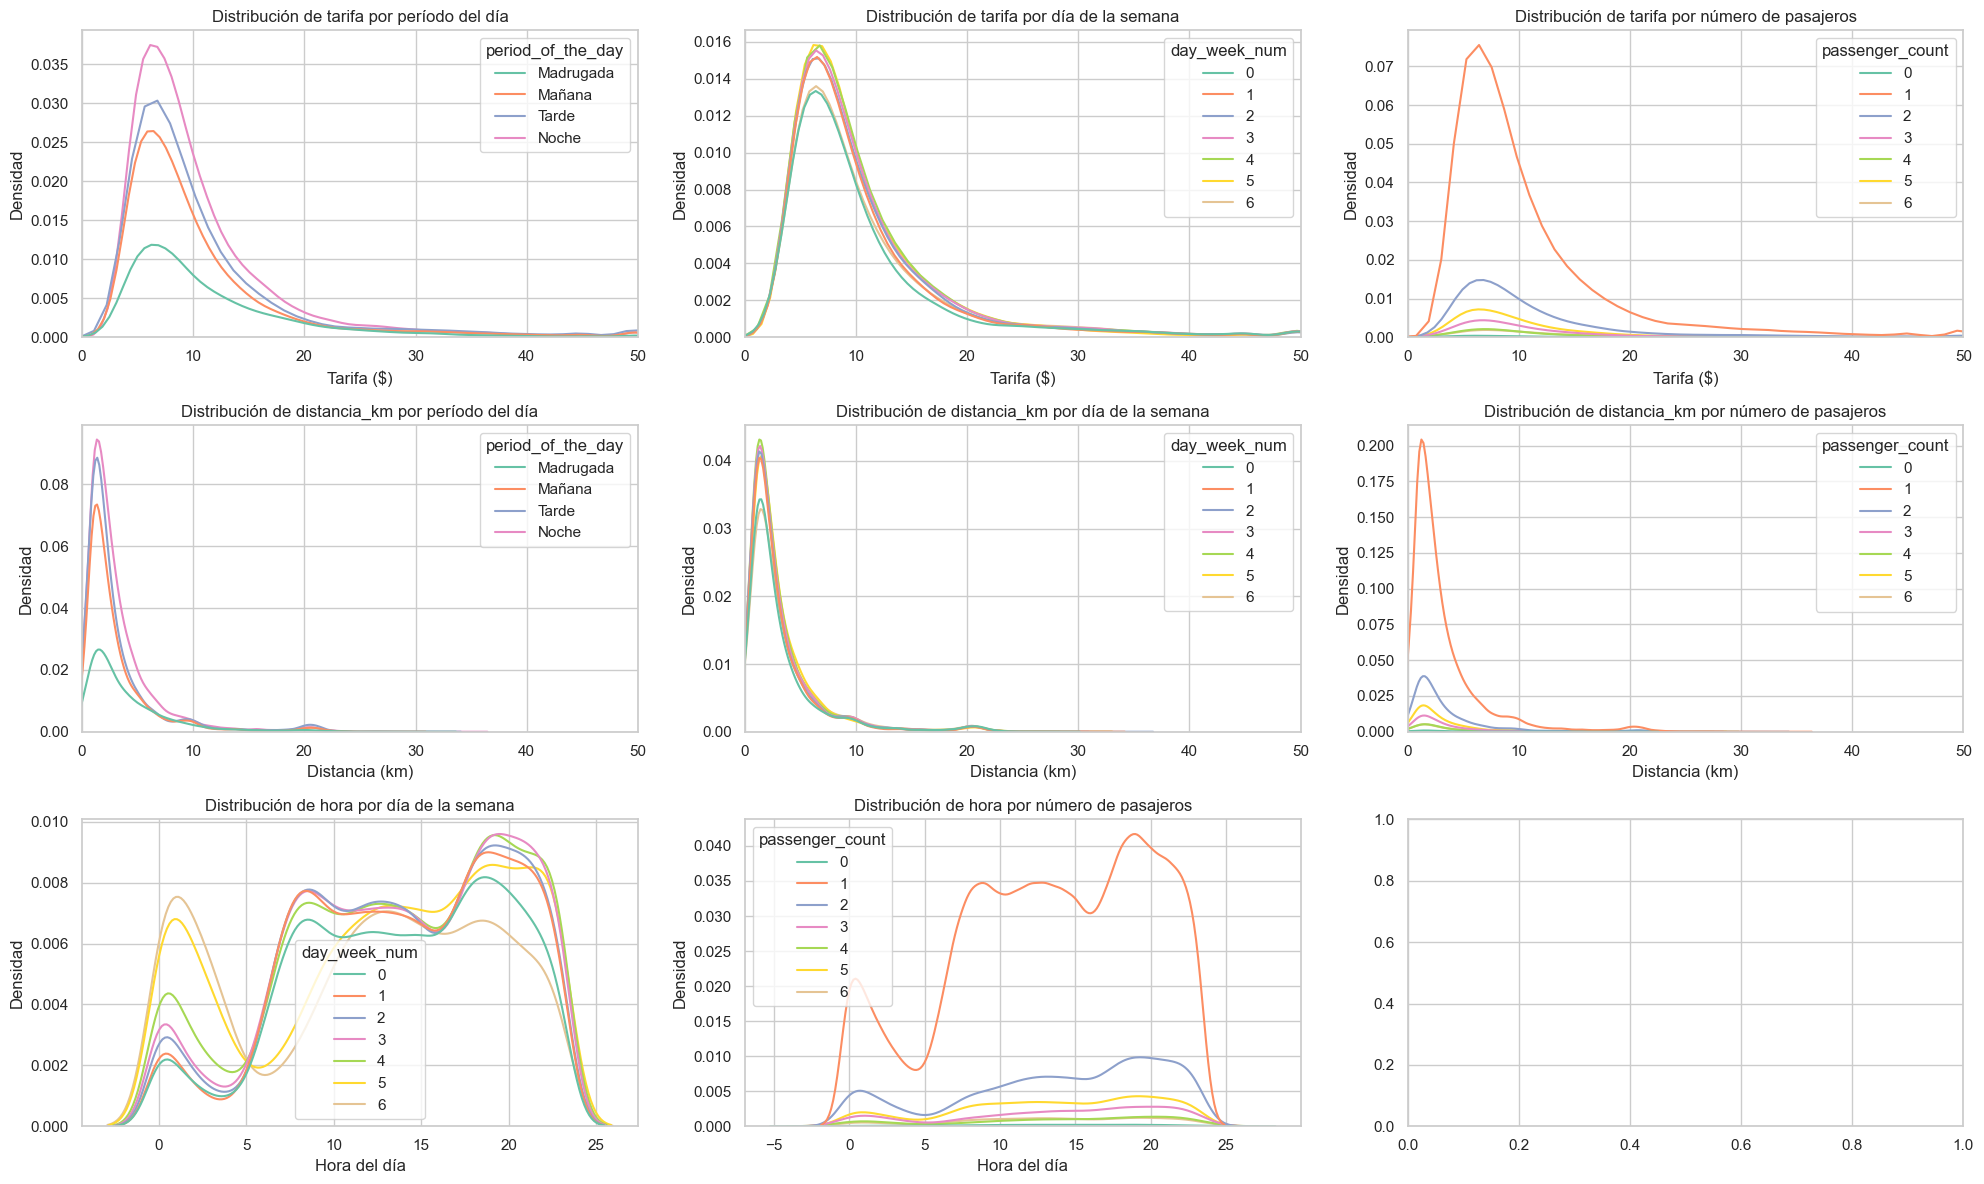

In [35]:
fig, ((ax1, ax2, ax3) ,(ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(nrows=3, ncols=3, figsize=(20, 12))

# Combinar X_train y y_train para los gráficos de target
data_combined = X_train.copy()
data_combined['target'] = y_train

# Gráfico 1: Distribución de la variable objetivo por período del día
sns.kdeplot(data=data_combined, x='target', hue='period_of_the_day', palette='Set2', ax=ax1)
ax1.set_xlim(0, 50)
ax1.set_title("Distribución de tarifa por período del día")
ax1.set_xlabel("Tarifa ($)")
ax1.set_ylabel("Densidad")

# Gráfico 2: Distribución de la variable objetivo por día de la semana
sns.kdeplot(data=data_combined, x='target', hue='day_week_num', palette='Set2', ax=ax2)
ax2.set_xlim(0, 50)
ax2.set_title("Distribución de tarifa por día de la semana")
ax2.set_xlabel("Tarifa ($)")
ax2.set_ylabel("Densidad")

# Gráfico 3: Distribución de la variable objetivo por número de pasajeros
sns.kdeplot(data=data_combined, x='target', hue='passenger_count', palette='Set2', ax=ax3)
ax3.set_xlim(0, 50)
ax3.set_title("Distribución de tarifa por número de pasajeros")
ax3.set_xlabel("Tarifa ($)")
ax3.set_ylabel("Densidad")

# Gráfico 4: Distribución de distancia_km por período del día
sns.kdeplot(data=X_train, x='distancia_km', hue='period_of_the_day', palette='Set2', ax=ax4)
ax4.set_xlim(0, 50)
ax4.set_title("Distribución de distancia_km por período del día")
ax4.set_xlabel("Distancia (km)")
ax4.set_ylabel("Densidad")

# Gráfico 5: Distribución de distancia_km por día de la semana
sns.kdeplot(data=X_train, x='distancia_km', hue='day_week_num', palette='Set2', ax=ax5)
ax5.set_xlim(0, 50)
ax5.set_title("Distribución de distancia_km por día de la semana")
ax5.set_xlabel("Distancia (km)")
ax5.set_ylabel("Densidad")

# Gráfico 6: Distribución de distancia_km por número de pasajeros
sns.kdeplot(data=X_train, x='distancia_km', hue='passenger_count', palette='Set2', ax=ax6)
ax6.set_xlim(0, 50)
ax6.set_title("Distribución de distancia_km por número de pasajeros")
ax6.set_xlabel("Distancia (km)")
ax6.set_ylabel("Densidad")

# Gráfico 7: Distribución de hora por día de la semana
sns.kdeplot(data=X_train, x='hora', hue='day_week_num', palette='Set2', ax=ax7)
ax7.set_title("Distribución de hora por día de la semana")
ax7.set_xlabel("Hora del día")
ax7.set_ylabel("Densidad")

# Gráfico 8: Distribución de hora por número de pasajeros
sns.kdeplot(data=X_train, x='hora', hue='passenger_count', palette='Set2', ax=ax8)
ax8.set_title("Distribución de hora por número de pasajeros")
ax8.set_xlabel("Hora del día")
ax8.set_ylabel("Densidad")

plt.tight_layout()
plt.show()

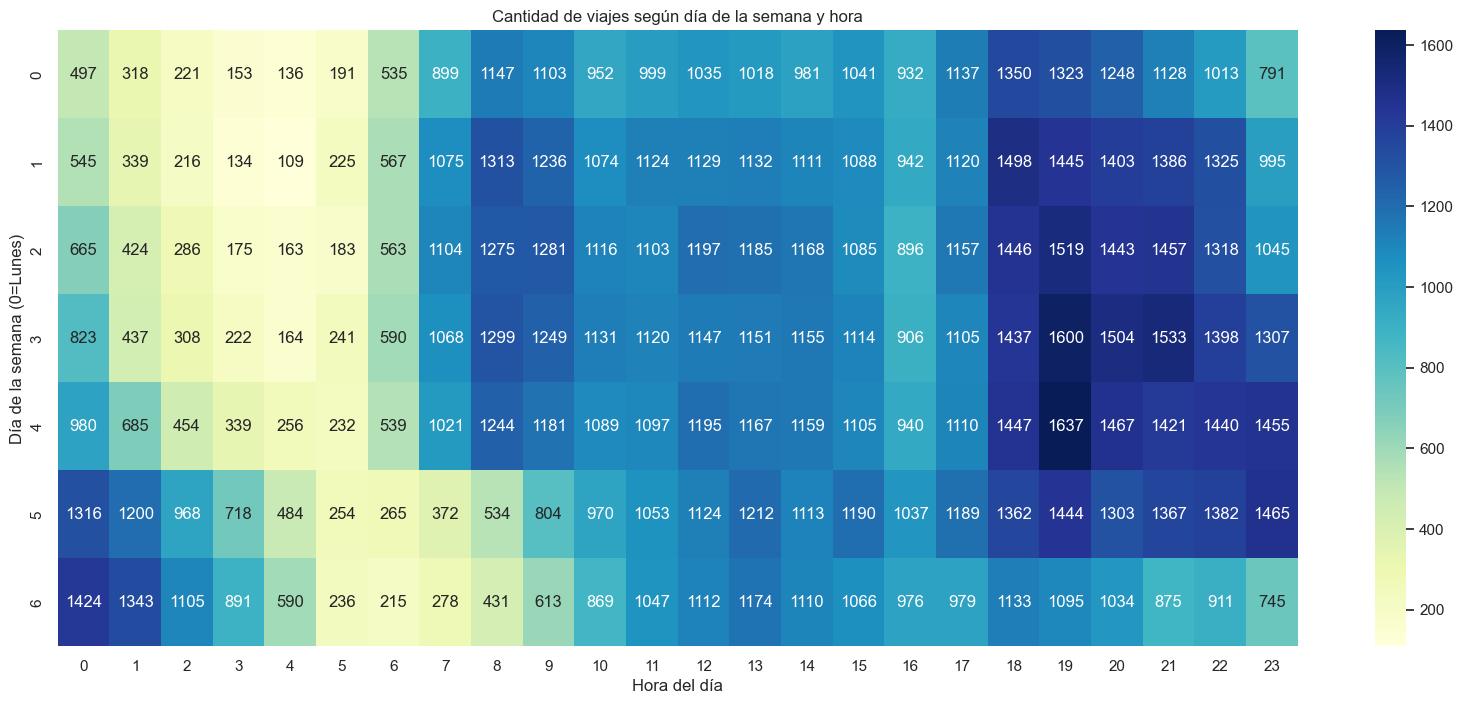

In [36]:
# Heatmap hora vs día de la semana

pivot_data = X_train.groupby(['day_week_num','hora']).size().unstack(fill_value=0)
plt.figure(figsize=(20,8))
sns.heatmap(pivot_data, cmap="YlGnBu", annot=True, fmt=".0f")
plt.title("Cantidad de viajes según día de la semana y hora")
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana (0=Lunes)")
plt.show()

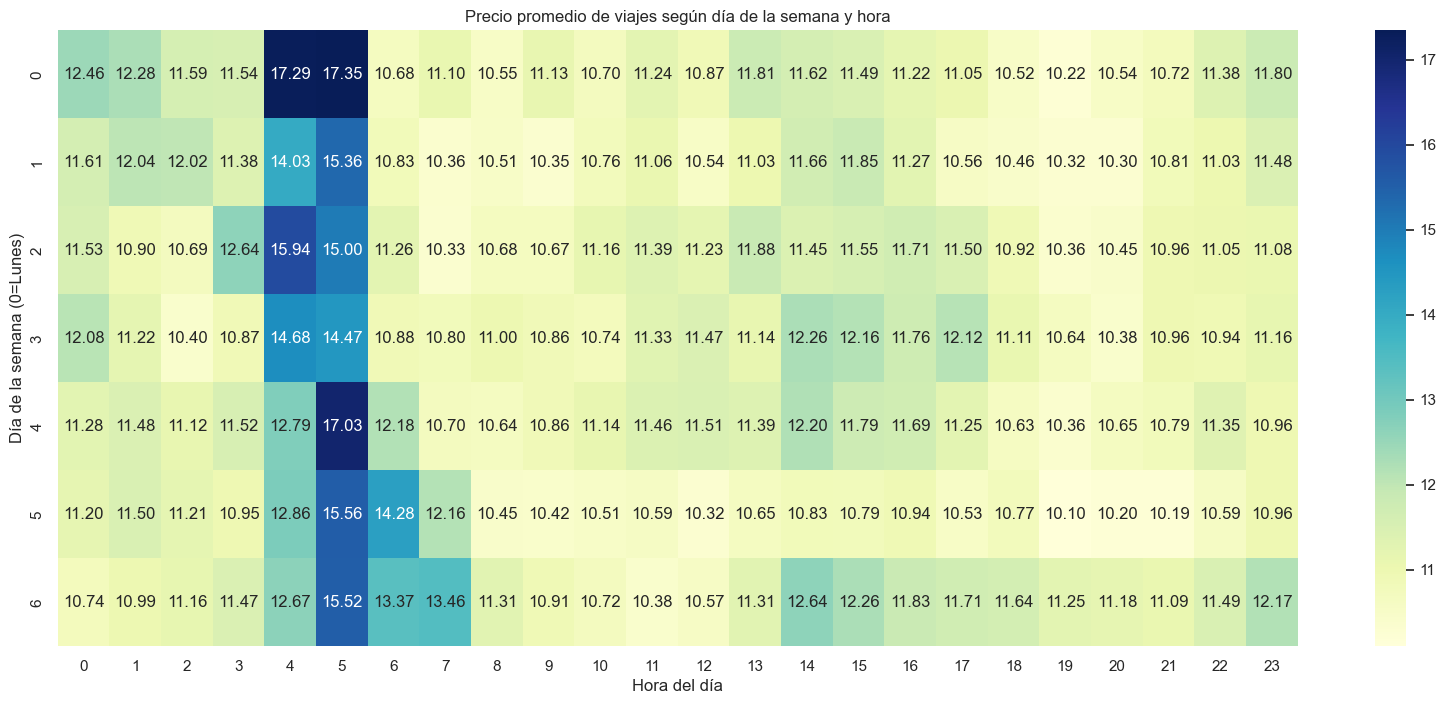

In [37]:
# Heatmap precio promedio vs día de la semana y hora

# Combinamos X_train y y_train
data_combined = X_train[['day_week_num', 'hora']].copy()
data_combined['target'] = y_train

# Agrupamos por día de la semana y hora, y calculamos el precio promedio
pivot_data = data_combined.groupby(['day_week_num', 'hora'])['target'].mean().unstack(fill_value=0)

plt.figure(figsize=(20, 8))
sns.heatmap(pivot_data, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Precio promedio de viajes según día de la semana y hora")
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana (0=Lunes)")
plt.show()

## Correlaciones

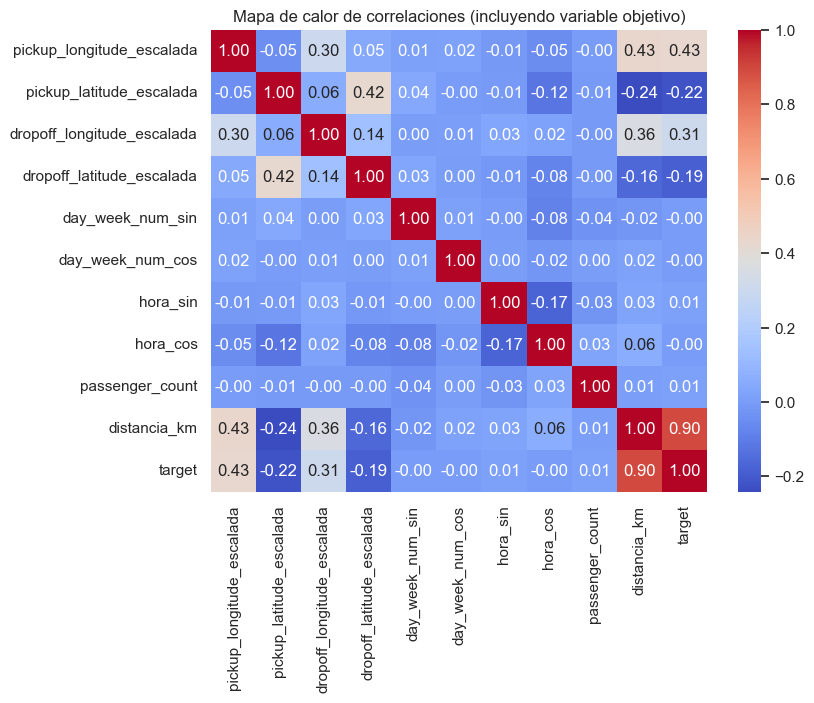

In [38]:
# Mapa de correlaciones incluyendo variable objetivo

data_combined = X_train[[    'pickup_longitude_escalada',
    'pickup_latitude_escalada',
    'dropoff_longitude_escalada',
    'dropoff_latitude_escalada',
    'day_week_num_sin',
    'day_week_num_cos',
    'hora_sin',
    'hora_cos',
    'passenger_count',
    'distancia_km']].copy()
data_combined['target'] = y_train

corr = data_combined.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de calor de correlaciones (incluyendo variable objetivo)")
plt.show()

- Vemos una correlacion muy alta entre la distancia del viaje y el precio del mismo.
- Tambien vemos una correlacion media entre los puntos de ascenso, la distancia, y el punto de descenso.

In [39]:
columnas_escaladas_especificas = [
    'pickup_longitude_desescalada',
    'pickup_latitude_desescalada',
    'dropoff_longitude_desescalada',
    'dropoff_latitude_desescalada',
    'day_week_num_sin',
    'day_week_num_cos',
    'hora_sin',
    'hora_cos',
    'passenger_count',
    'distancia_km'
]

columnas_existentes = [col for col in columnas_escaladas_especificas if col in X_train.columns]

X_train_scaled = X_train[columnas_existentes].copy()

X_test_scaled = X_test[columnas_existentes].copy()

In [40]:
X_train_scaled.head()

,pickup_longitude_desescalada,pickup_latitude_desescalada,dropoff_longitude_desescalada,dropoff_latitude_desescalada,day_week_num_sin,day_week_num_cos,hora_sin,hora_cos,passenger_count,distancia_km
153248,-73.978585,40.748388,-73.976913,40.784958,0.433884,-0.900969,-0.707107,0.707107,1,4.068841
67802,-73.978198,40.752533,-73.909752,40.874372,0.974928,-0.222521,-0.500000,0.866025,1,14.721602
148889,-73.994242,40.751227,-73.999432,40.762037,-0.781831,0.623490,0.866025,-0.500000,1,1.279042
103093,-73.951705,40.778330,-73.956050,40.777560,-0.974928,-0.222521,-0.258819,0.965926,2,0.375743
104681,-73.989120,40.736932,-73.782890,40.643947,-0.781831,0.623490,-0.258819,-0.965926,1,20.229724


In [41]:
X_test_scaled.head()

,pickup_longitude_desescalada,pickup_latitude_desescalada,dropoff_longitude_desescalada,dropoff_latitude_desescalada,day_week_num_sin,day_week_num_cos,hora_sin,hora_cos,passenger_count,distancia_km
119737,-74.000458,40.723990,-73.989682,40.725797,0.000000,1.000000,-0.258819,9.659258e-01,1,0.930050
72272,-73.975551,40.750772,-73.974627,40.751088,-0.781831,0.623490,-0.707107,7.071068e-01,5,0.085432
158154,-73.955315,40.779068,-73.970558,40.764650,0.433884,-0.900969,-1.000000,-1.836970e-16,5,2.053762
65426,-73.870920,40.773705,-73.964346,40.797100,0.974928,-0.222521,-0.866025,5.000000e-01,3,8.284795
30074,-73.992195,40.748958,-73.987078,40.743065,0.000000,1.000000,0.866025,-5.000000e-01,1,0.784349


## Escalado

In [42]:
# Columnas a escalar
cols_coordenadas = ['pickup_longitude_desescalada', 'pickup_latitude_desescalada', 'dropoff_longitude_desescalada', 'dropoff_latitude_desescalada','distancia_km']

# Creamos un nuevo scaler para las coordenadas
scaler_coordenadas = StandardScaler()

# Escalamos las columnas en X_train_scaled
X_train_scaled[cols_coordenadas] = scaler_coordenadas.fit_transform(X_train_scaled[cols_coordenadas])

# Escalamos las columnas en X_test_scaled usando el mismo scaler
X_test_scaled[cols_coordenadas] = scaler_coordenadas.transform(X_test_scaled[cols_coordenadas])

In [43]:
X_train_scaled.head()

,pickup_longitude_desescalada,pickup_latitude_desescalada,dropoff_longitude_desescalada,dropoff_latitude_desescalada,day_week_num_sin,day_week_num_cos,hora_sin,hora_cos,passenger_count,distancia_km
153248,-0.089151,-0.089633,-0.068192,1.118253,0.433884,-0.900969,-0.707107,0.707107,1,0.234473
67802,-0.077773,0.066213,1.934584,4.070241,0.974928,-0.222521,-0.500000,0.866025,1,3.238947
148889,-0.549457,0.017109,-0.739720,0.361520,-0.781831,0.623490,0.866025,-0.500000,1,-0.552354
103093,0.701104,1.036141,0.553954,0.874010,-0.974928,-0.222521,-0.258819,0.965926,2,-0.807118
104681,-0.398873,-0.520362,5.717674,-3.537201,-0.781831,0.623490,-0.258819,-0.965926,1,4.792442


In [44]:
X_test_scaled.head()

,pickup_longitude_desescalada,pickup_latitude_desescalada,dropoff_longitude_desescalada,dropoff_latitude_desescalada,day_week_num_sin,day_week_num_cos,hora_sin,hora_cos,passenger_count,distancia_km
119737,-0.732203,-1.006961,-0.448970,-0.834937,0.000000,1.000000,-0.258819,9.659258e-01,1,-0.650783
72272,0.000041,-0.000008,-0.000013,0.000028,-0.781831,0.623490,-0.707107,7.071068e-01,5,-0.888996
158154,0.594972,1.063889,0.121318,0.447788,0.433884,-0.900969,-1.000000,-1.836970e-16,5,-0.333854
65426,3.076132,0.862248,0.306563,1.519119,0.974928,-0.222521,-0.866025,5.000000e-01,3,1.423528
30074,-0.489276,-0.068202,-0.371317,-0.264837,0.000000,1.000000,0.866025,-5.000000e-01,1,-0.691876


# Regresion lineal

In [45]:
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
# Predicciones sobre el conjunto de entrenamiento
y_pred_train_rl = model_lr.predict(X_train_scaled)

# Métricas
mse_train_rl = mean_squared_error(y_train, y_pred_train_rl)
rmse_train_rl = math.sqrt(mse_train_rl)
r2_train_rl = r2_score(y_train, y_pred_train_rl)

print("Métricas en el conjunto de entrenamiento:")
print(f'- Error Cuadrático Medio: {round(mse_train_rl, 3)}')
print(f'- Raíz Error Cuadrático Medio: {round(rmse_train_rl, 3)}')
print(f'- Coeficiente de Determinación: {round(r2_train_rl, 3)}')

Métricas en el conjunto de entrenamiento:
- Error Cuadrático Medio: 15.712
- Raíz Error Cuadrático Medio: 3.964
- Coeficiente de Determinación: 0.812


Con estos resultados sobre el conjunto de entrenamiento podemos ver que el modelo explica un 81.2% de la variabilidad de los datos, con un error promedio de $3.96 dolares.

In [ ]:
# Predicciones sobre el conjunto de test
y_pred_test_rl = model_lr.predict(X_test_scaled)

# Métricas
mse_test_rl = mean_squared_error(y_test, y_pred_test_rl)
rmse_test_rl = math.sqrt(mse_test_rl)
r2_test_rl = r2_score(y_test, y_pred_test_rl)

print("Métricas en el conjunto de testeo:")
print(f'- Error Cuadrático Medio: {round(mse_test_rl, 3)}')
print(f'- Raíz Error Cuadrático Medio: {round(rmse_test_rl, 3)}')
print(f'- Coeficiente de Determinación: {round(r2_test_rl, 3)}')


Métricas en el conjunto de testeo:
Error Cuadrático Medio: 41.344
Raíz Error Cuadrático Medio: 6.43
Coeficiente de Determinación: 0.611


Con estos resultados sobre el conjunto de pruebas observamos que el modelo explica un 61.1% de la variabilidad de los datos, con un error promedio de $6.43 dolares. Esto representa un error medio significativo en comparacion con el promedio (11.35) y la mediana (8.5).

In [48]:
# Coeficientes de la recta de regresión
intercepto = model_lr.intercept_
print(f"Intercepto: {intercepto}")
df_coeficientes = pd.DataFrame(
                        {'predictor': X_train_scaled.columns,
                         'coef': model_lr.coef_.flatten()}
                  )

df_coeficientes[df_coeficientes.coef != 0]

Intercepto: 10.941723332318645


,predictor,coef
0,pickup_longitude_desescalada,0.499927
1,pickup_latitude_desescalada,0.124706
2,dropoff_longitude_desescalada,-0.144326
3,dropoff_latitude_desescalada,-0.502677
4,day_week_num_sin,0.174246
5,day_week_num_cos,-0.236066
6,hora_sin,-0.268229
7,hora_cos,-0.725104
8,passenger_count,0.049154
9,distancia_km,8.018876


Vemos que el coeficiente que mas explica, por mucha diferencia, es la distancia.

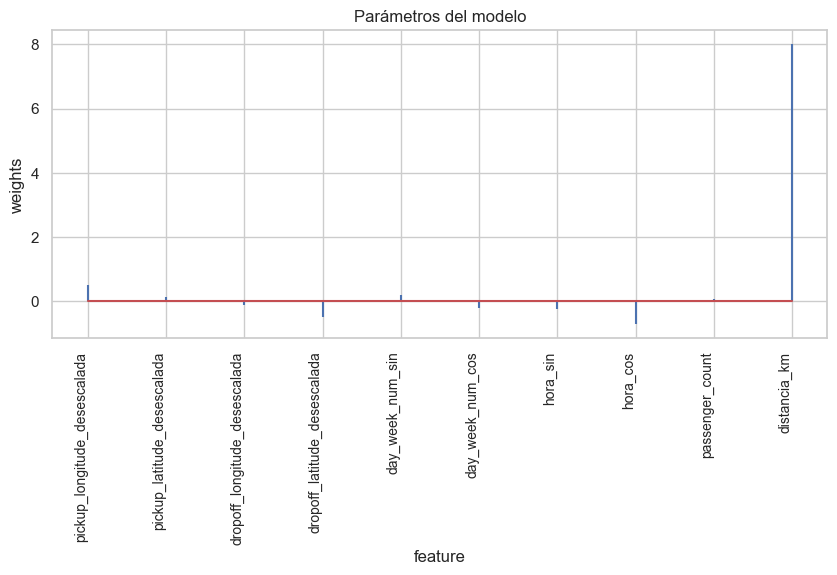

In [49]:
# Coeficientes del modelo

df_coeficientes = pd.DataFrame({'predictor': X_train_scaled.columns, 'coef': df_coeficientes.coef})

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=10)
ax.set_xlabel('feature')
ax.set_ylabel('weights')
ax.set_title('Parámetros del modelo')
plt.show()

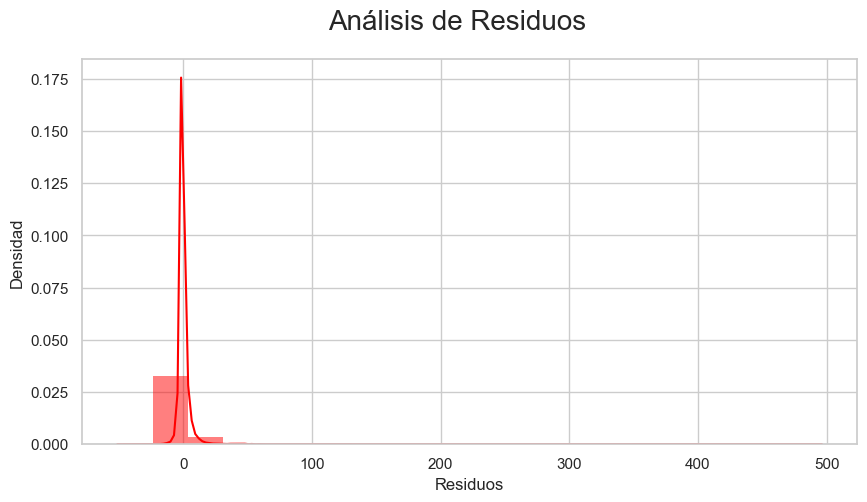

In [50]:
# Análisis de Residuos
fig = plt.figure(figsize=(10,5))

sns.histplot((y_test - y_pred_test_rl), color="red", kde=True, stat="density", linewidth=0, bins=20)
fig.suptitle('Análisis de Residuos', fontsize = 20)
plt.xlabel('Residuos')
plt.ylabel('Densidad')
plt.show()

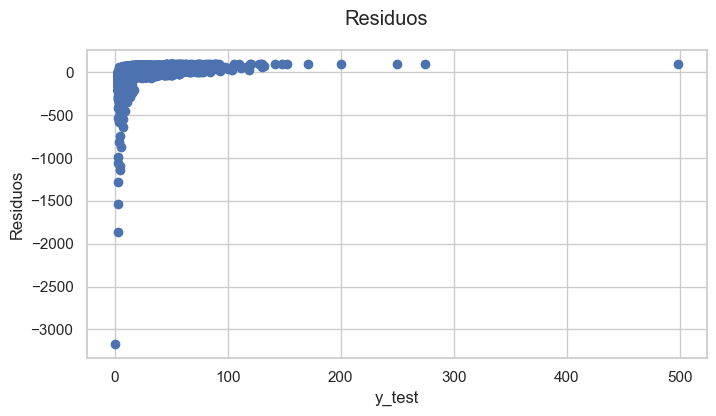

In [51]:
fig = plt.figure(figsize=(8,4))
fig.suptitle('Residuos')
plt.xlabel('y_test')
plt.ylabel('Residuos')
plt.scatter(y_test,100*(y_test-y_pred_test_rl)/y_test)
plt.show()

Vemos que la mayoria de los residuos estan cerca del 0, por lo que el modelo capta bien la variable en la mayoria de los casos, pero no estaria manejando bien los valores extremos.

# Gradiente Descendente

In [52]:
# definición de funciones de pérdida distintas y sus derivadas.
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mse_gradient(X, y_true, y_pred):
    n = X.shape[0]
    return -(2/n) * (X.T @ (y_true - y_pred))

def mae_loss(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mae_gradient(X, y_true, y_pred):
    n = X.shape[0]
    return -(1/n) * (X.T @ np.sign(y_true - y_pred))

In [53]:
def plot_loss(train_errors, val_errors):
    # gráfico de errores.
    plt.figure(figsize=(12, 4))
    plt.plot(train_errors, label='train_loss')
    plt.plot(val_errors, label='val_loss')
    plt.xlabel('Iteración')
    plt.ylabel('Loss')
    plt.title('Evolución de función de pérdida vs iteraciones')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_parameters(coef_history):
    # gráfico de coeficientes.
    coef_history = np.array(coef_history)
    plt.figure(figsize=(12, 4))
    for j in range(coef_history.shape[1]):
        plt.plot(coef_history[:, j], label=f'beta_{j}')
    plt.xlabel('Iteración')
    plt.ylabel('Valor del coeficiente')
    plt.title('Evolución de los coeficientes')
    plt.legend()
    plt.grid(True)
    plt.show()

In [55]:
def gradient_descent(X_train, y_train, X_val, y_val, lr=0.01, epochs=100, grad_fn=mse_gradient):
    """
    Gradient Descent para regresión lineal con tracking de errores y coeficientes.

    Parámetros:
    -----------
    X_train : ndarray de shape (n, m)
        Datos de entrenamiento.
    y_train : ndarray de shape (n, 1)
        Etiquetas de entrenamiento.
    X_val : ndarray de shape (p, m)
        Datos de validación.
    y_val : ndarray de shape (p, 1)
        Etiquetas de validación.
    lr : float, opcional (default=0.01)
        Tasa de aprendizaje.
    epochs : int, opcional (default=100)
        Número de iteraciones.
    grad_fn : (default = mse_gradient)
        Función de pérdida.

    Devuelve:
    --------
    W : ndarray de shape (m+1, 1)
        Pesos finales aprendidos.
    """

    y_train = y_train.reshape(-1, 1)
    y_val = y_val.reshape(-1, 1)

    # se guardan dimensiones
    n, m = X_train.shape
    o = X_val.shape[0]

    # se agrega columna de unos a las matrices X para considerar los términos independientes (no hacerlo implica forzar término independiente a nulo)
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val = np.hstack((np.ones((o, 1)), X_val))

    # se inicializan pesos aleatorios (m+1)x1
    W = np.random.randn(m+1, 1)

    # listas para guardar evolución de errores y coeficientes a lo largo de las iteraciones
    # los coeficientes ya tienen un valor inicial (W).
    train_errors, val_errors, coef_history = [], [], [W.flatten()]

    for _ in range(epochs):
        # como ya hay una inicialización de los coeficientes, se calcula con ellos el ajuste al conjunto de entrenamiento y validación.
        y_pred_train = X_train @ W
        y_pred_val = X_val @ W

        error_train = y_train - y_pred_train
        error_val = y_val - y_pred_val

        train_mse = np.mean(error_train ** 2)
        val_mse = np.mean(error_val ** 2)

        train_errors.append(train_mse)
        val_errors.append(val_mse)

        # calculo gradiente , uso la función que se pasa como parámetro.
        gradient = grad_fn(X_train, y_train, y_pred_train)
        W -= lr * gradient

        # se guarda coeficientes para plot.
        coef_history.append(W.flatten())

    plot_loss(train_errors, val_errors)
    plot_parameters(coef_history)

    return W

In [56]:
def stochastic_gradient_descent(X_train, y_train, X_val, y_val, lr=0.01, epochs=100, grad_fn=mse_gradient, batch_size=1):
    """
    Stochastic Gradient Descent (SGD) para regresión lineal con tracking de errores y coeficientes.

    Parámetros:
    -----------
    X_train, y_train, X_val, y_val : datos de entrenamiento y validación
    lr : tasa de aprendizaje
    epochs : número de pasadas completas sobre el dataset
    grad_fn : función de gradiente (default = mse_gradient)
    batch_size : tamaño del lote (1 = SGD puro, >1 = Mini-batch SGD)

    Devuelve:
    ---------
    W : ndarray de shape (m+1, 1)
        Pesos finales aprendidos.
    """

    y_train = y_train.reshape(-1, 1)
    y_val = y_val.reshape(-1, 1)

    n, m = X_train.shape
    o = X_val.shape[0]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val = np.hstack((np.ones((o, 1)), X_val))

    W = np.random.randn(m+1, 1)

    train_errors, val_errors, coef_history = [], [], [W.flatten()]

    for _ in range(epochs):
        # se mezclan índices para que cada época tenga distinto orden de muestras
        indices = np.random.permutation(n)

        for i in range(0, n, batch_size):
            batch_idx = indices[i:i+batch_size]
            X_batch = X_train[batch_idx]
            y_batch = y_train[batch_idx]

            y_pred_batch = X_batch @ W
            gradient = grad_fn(X_batch, y_batch, y_pred_batch)
            W -= lr * gradient

        # errores globales después de cada época
        y_pred_train = X_train @ W
        y_pred_val = X_val @ W
        train_errors.append(np.mean((y_train - y_pred_train) ** 2))
        val_errors.append(np.mean((y_val - y_pred_val) ** 2))

        coef_history.append(W.flatten())

    plot_loss(train_errors, val_errors)
    plot_parameters(coef_history)

    return W

In [57]:
def mini_batch_gradient_descent(X_train, y_train, X_val, y_val, lr=0.01, epochs=100, batch_size=32, grad_fn=mse_gradient):
    """
    Mini-Batch Gradient Descent (MBGD) para regresión lineal con tracking de errores y coeficientes.
    Notar que esta función se puede usar directamente para los tres casos: si batch_size = 1, es el caso de SGD.
    Si batch_size = len(X), es el caso de GD.

    Parámetros:
    -----------
    X_train, y_train, X_val, y_val : datos de entrenamiento y validación
    lr : tasa de aprendizaje
    epochs : número de pasadas completas sobre el dataset
    batch_size : tamaño de cada mini-lote
    grad_fn : función de gradiente (default = mse_gradient)

    Devuelve:
    ---------
    W : ndarray de shape (m+1, 1)
        Pesos finales aprendidos.
    """

    y_train = y_train.reshape(-1, 1)
    y_val = y_val.reshape(-1, 1)

    n, m = X_train.shape
    o = X_val.shape[0]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val = np.hstack((np.ones((o, 1)), X_val))

    W = np.random.randn(m+1, 1)

    train_errors, val_errors, coef_history = [], [], [W.flatten()]

    for _ in range(epochs):
        indices = np.random.permutation(n)

        # usamos batches para el cálculo.
        for i in range(0, n, batch_size):
            batch_idx = indices[i:i+batch_size]
            X_batch = X_train[batch_idx]
            y_batch = y_train[batch_idx]

            y_pred_batch = X_batch @ W
            gradient = grad_fn(X_batch, y_batch, y_pred_batch)
            W -= lr * gradient

        y_pred_train = X_train @ W
        y_pred_val = X_val @ W
        train_errors.append(np.mean((y_train - y_pred_train) ** 2))
        val_errors.append(np.mean((y_val - y_pred_val) ** 2))

        coef_history.append(W.flatten())

    plot_loss(train_errors, val_errors)
    plot_parameters(coef_history)

    return W

In [58]:
X_train_gd, X_val_gd, y_train_gd, y_val_gd = train_test_split(X_train_scaled, y_train, test_size=0.125, random_state=42)

In [59]:
# Convertimos a arrays de numpy
X_train_gd = np.array(X_train_gd)
X_val_gd = np.array(X_val_gd)
y_train_gd = np.array(y_train_gd).reshape(-1, 1)
y_val_gd = np.array(y_val_gd).reshape(-1, 1)
X_test_scaled = np.array(X_test_scaled)
y_test = np.array(y_test).reshape(-1, 1)

In [60]:
# Verificar shapes
print("Shapes después de conversión:")
print(f"X_train: {X_train_gd.shape}")
print(f"X_val: {X_val_gd.shape}")
print(f"y_train: {y_train_gd.shape}")
print(f"y_val: {y_val_gd.shape}")

Shapes después de conversión:
X_train: (139982, 10)
X_val: (19998, 10)
y_train: (139982, 1)
y_val: (19998, 1)


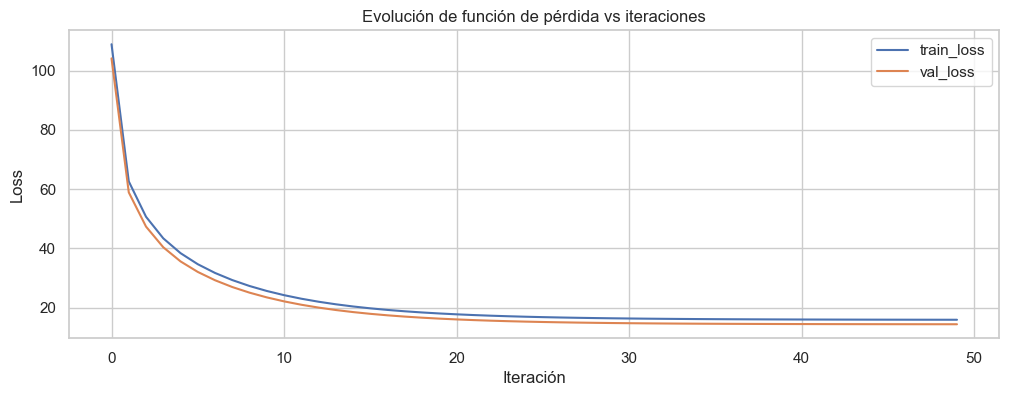

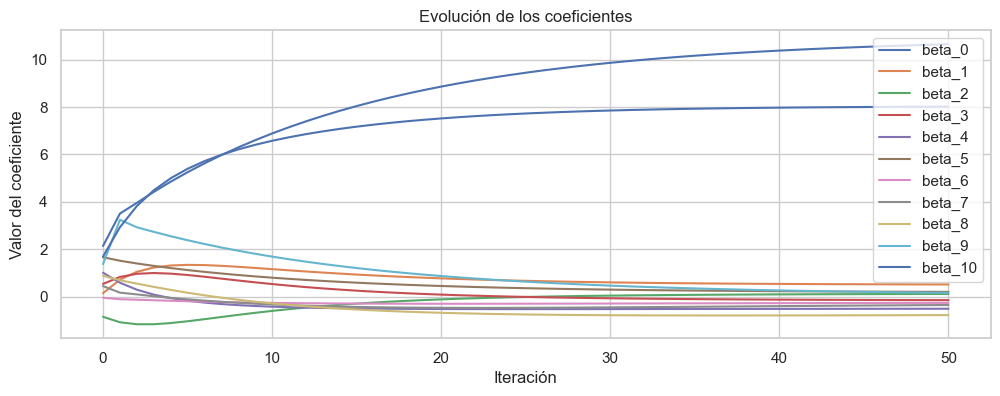

array([[10.65043108],
       [ 0.5140108 ],
       [ 0.11283392],
       [-0.14793808],
       [-0.51066817],
       [ 0.20152692],
       [-0.26230205],
       [-0.3534768 ],
       [-0.77908854],
       [ 0.15973096],
       [ 8.01878971]])

In [61]:
gradient_descent(X_train_gd, y_train_gd, X_val_gd, y_val_gd, lr=0.1, epochs=50)

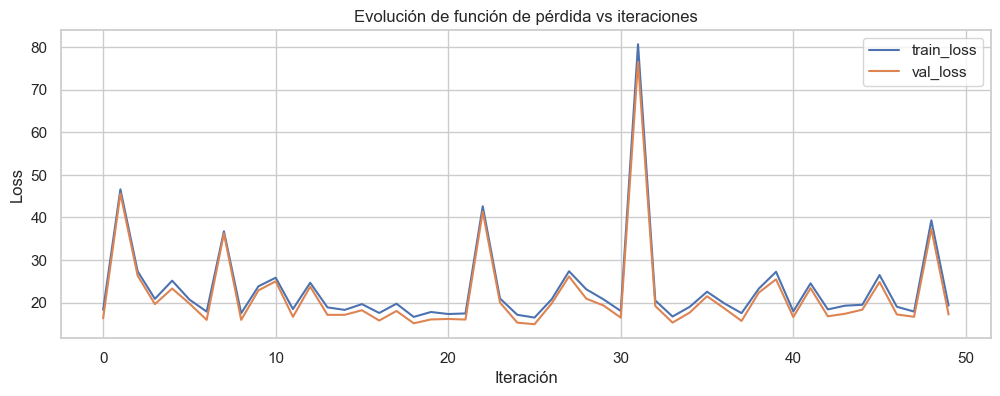

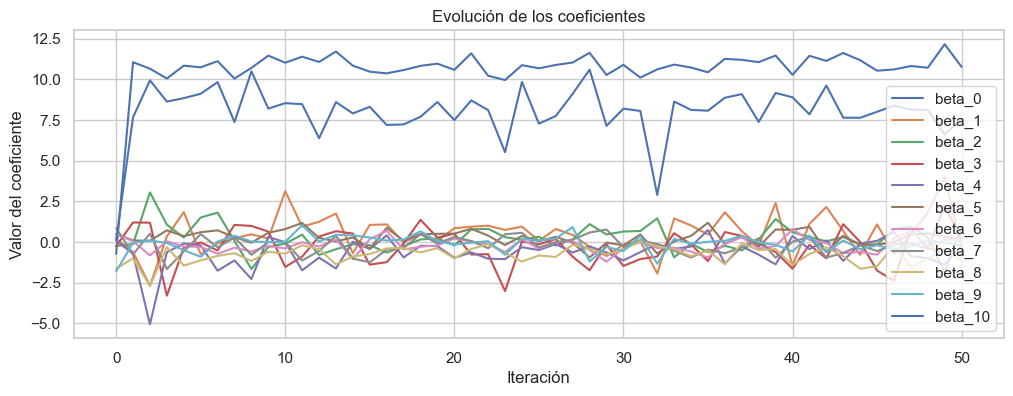

array([[10.76616374],
       [-0.38779428],
       [ 1.00257485],
       [ 0.15372461],
       [-0.18933503],
       [ 0.12983165],
       [ 0.15383814],
       [-0.78055406],
       [-1.17605307],
       [-0.22032525],
       [ 7.56521538]])

In [63]:
stochastic_gradient_descent(X_train_gd, y_train_gd, X_val_gd, y_val_gd, lr=0.01, epochs=50)

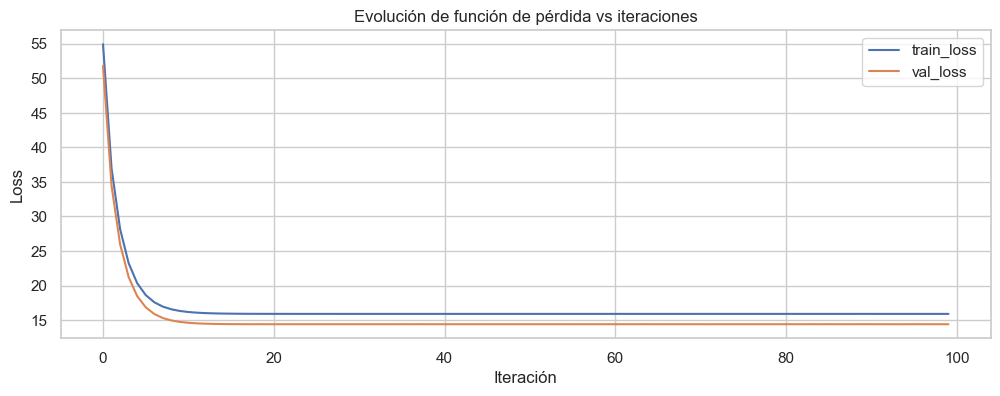

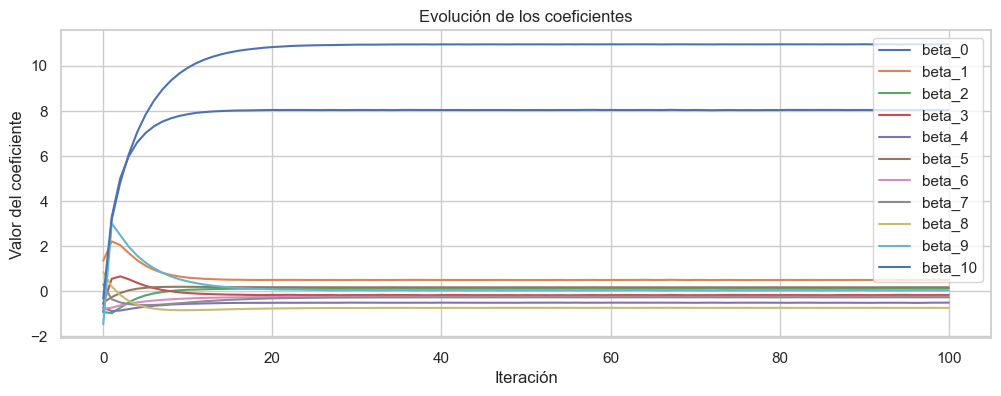

array([[10.95205289],
       [ 0.50281795],
       [ 0.12817903],
       [-0.16184778],
       [-0.50011463],
       [ 0.18123206],
       [-0.2421532 ],
       [-0.26490038],
       [-0.7316889 ],
       [ 0.04985914],
       [ 8.03493225]])

In [64]:
mini_batch_gradient_descent(X_train_gd, y_train_gd, X_val_gd, y_val_gd, lr=0.001, epochs=100, batch_size=400)

> Probar con los tres métodos de gradiente descendiente. ¿Qué observan? Incorporar gráficas de Error vs Iteraciones (loss vs epochs). Comentar qué observan en estos gráficos.

- En gradiente descendiente, si achicamos el learning rate desde 0.1 y agregando decimales, se observa que tarda mas en "plancaharse". Pero si es 1 comienza con un error muy bajo y sube abruptamente a partir de, mas o menos, las 47 epocas.
- En los otros dos, jugamos con los valores y obtuvimos resultados similares a los que se pueden apreciar en los graficos


# Regularizacion

### Lasso

In [65]:
# Lasso con alpha=0.1
lasso = Lasso(alpha=1, max_iter=1000, random_state=42)
lasso.fit(X_train_scaled, y_train)

# Predicciones sobre el conjunto de entrenamiento
y_pred_train_lasso = lasso.predict(X_train_scaled)

# Métricas de entrenamiento
mse_train_lasso = mean_squared_error(y_train, y_pred_train_lasso)
rmse_train_lasso = math.sqrt(mse_train_lasso)
r2_train_lasso = r2_score(y_train, y_pred_train_lasso)

print("RESULTADOS DEL MODELO LASSO:")

print(f"\nMÉTRICAS EN ENTRENAMIENTO:")
print(f"- Error Cuadrático Medio (MSE): {mse_train_lasso:.3f}")
print(f"- Raíz del Error Cuadrático (RMSE): {rmse_train_lasso:.3f}")
print(f"- Coeficiente de Determinación (R²): {r2_train_lasso:.3f}")

RESULTADOS DEL MODELO LASSO:

MÉTRICAS EN ENTRENAMIENTO:
- Error Cuadrático Medio (MSE): 17.436
- Raíz del Error Cuadrático (RMSE): 4.176
- Coeficiente de Determinación (R²): 0.791


In [70]:
# Predicciones sobre el conjunto de test
y_pred_test_lasso = lasso.predict(X_test_scaled)

# Métricas de test
mse_test_lasso = mean_squared_error(y_test, y_pred_test_lasso)
rmse_test_lasso = math.sqrt(mse_test_lasso)
r2_test_lasso = r2_score(y_test, y_pred_test_lasso)

print(f"MÉTRICAS EN TEST:")
print(f"- Error Cuadrático Medio (MSE): {mse_test_lasso:.3f}")
print(f"- Raíz del Error Cuadrático (RMSE): {rmse_test_lasso:.3f}")
print(f"- Coeficiente de Determinación (R²): {r2_test_lasso:.3f}")

MÉTRICAS EN TEST:
- Error Cuadrático Medio (MSE): 42.719
- Raíz del Error Cuadrático (RMSE): 6.536
- Coeficiente de Determinación (R²): 0.598


## Ridge

In [71]:
# Ridge con alpha=0.1
ridge = Ridge(alpha=0.1, max_iter=1000, random_state=42)
ridge.fit(X_train_scaled, y_train)

# Predicciones sobre el conjunto de entrenamiento
y_pred_train_ridge = ridge.predict(X_train_scaled)

# Métricas de entrenamiento
mse_train_ridge = mean_squared_error(y_train, y_pred_train_ridge)
rmse_train_ridge = math.sqrt(mse_train_ridge)
r2_train_ridge = r2_score(y_train, y_pred_train_ridge)

print("RESULTADOS DEL MODELO RIDGE")

print(f"\nMÉTRICAS EN ENTRENAMIENTO:")
print(f"  Error Cuadrático Medio (MSE): {mse_train_ridge:.3f}")
print(f"  Raíz del Error Cuadrático (RMSE): {rmse_train_ridge:.3f}")
print(f"  Coeficiente de Determinación (R²): {r2_train_ridge:.3f}")

RESULTADOS DEL MODELO RIDGE

MÉTRICAS EN ENTRENAMIENTO:
  Error Cuadrático Medio (MSE): 15.712
  Raíz del Error Cuadrático (RMSE): 3.964
  Coeficiente de Determinación (R²): 0.812


In [72]:
# Predicciones sobre el conjunto de test
y_pred_test_ridge = ridge.predict(X_test_scaled)

# Métricas de test
mse_test_ridge = mean_squared_error(y_test, y_pred_test_ridge)
rmse_test_ridge = math.sqrt(mse_test_ridge)
r2_test_ridge = r2_score(y_test, y_pred_test_ridge)

print(f"MÉTRICAS EN TEST:")
print(f"  Error Cuadrático Medio (MSE): {mse_test_ridge:.3f}")
print(f"  Raíz del Error Cuadrático (RMSE): {rmse_test_ridge:.3f}")
print(f"  Coeficiente de Determinación (R²): {r2_test_ridge:.3f}")

MÉTRICAS EN TEST:
  Error Cuadrático Medio (MSE): 41.344
  Raíz del Error Cuadrático (RMSE): 6.430
  Coeficiente de Determinación (R²): 0.611


In [73]:
# Mostrar coeficientes
print("Coeficientes del modelo Ridge:")
print(ridge.coef_)
print(ridge.score(X_train_scaled, y_train))

Coeficientes del modelo Ridge:
[ 0.49992925  0.12470433 -0.14432421 -0.50267714  0.17424552 -0.23606568
 -0.26822794 -0.72510274  0.049154    8.01886883]
0.8119824440483051


## Elastic Net

In [74]:
# Elastic Net con alpha=0.1 y l1_ratio=0.5
elasticnet = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=1000, random_state=42)
elasticnet.fit(X_train_scaled, y_train)

# Predicciones sobre el conjunto de entrenamiento
y_pred_train_en = elasticnet.predict(X_train_scaled)

# Métricas de entrenamiento
mse_train_en = mean_squared_error(y_train, y_pred_train_en)
rmse_train_en = math.sqrt(mse_train_en)
r2_train_en = r2_score(y_train, y_pred_train_en)

print("RESULTADOS DEL MODELO Elastic Net")

print(f"\nMÉTRICAS EN ENTRENAMIENTO:")
print(f"  Error Cuadrático Medio (MSE): {mse_train_en:.3f}")
print(f"  Raíz del Error Cuadrático (RMSE): {rmse_train_en:.3f}")
print(f"  Coeficiente de Determinación (R²): {r2_train_en:.3f}")

RESULTADOS DEL MODELO Elastic Net

MÉTRICAS EN ENTRENAMIENTO:
  Error Cuadrático Medio (MSE): 15.980
  Raíz del Error Cuadrático (RMSE): 3.998
  Coeficiente de Determinación (R²): 0.809


In [75]:
# Predicciones sobre el conjunto de test
y_pred_test_en = elasticnet.predict(X_test_scaled)

# Métricas de test
mse_test_en = mean_squared_error(y_test, y_pred_test_en)
rmse_test_en = math.sqrt(mse_test_en)
r2_test_en = r2_score(y_test, y_pred_test_en)

print(f"MÉTRICAS EN TEST:")
print(f"  Error Cuadrático Medio (MSE): {mse_test_en:.3f}")
print(f"  Raíz del Error Cuadrático (RMSE): {rmse_test_en:.3f}")
print(f"  Coeficiente de Determinación (R²): {r2_test_en:.3f}")

MÉTRICAS EN TEST:
  Error Cuadrático Medio (MSE): 41.342
  Raíz del Error Cuadrático (RMSE): 6.430
  Coeficiente de Determinación (R²): 0.611


> Probar con los métodos de regularización (Lasso, Ridge, Elastic Net). Usar un rango amplio de coeficientes de regularización

# Comparacion modelos

In [76]:
# Crear DataFrame de comparación
comparison_data = {
    'Modelo': ['Regresión Lineal', 'Lasso', 'Ridge', 'Elastic Net'],
    'MSE_Train': [mse_train_rl, mse_train_lasso, mse_train_ridge, mse_train_en],
    'RMSE_Train': [rmse_train_rl, rmse_train_lasso, rmse_train_ridge, rmse_train_en],
    'R2_Train': [r2_train_rl, r2_train_lasso, r2_train_ridge, r2_train_en],
    'MSE_Test': [mse_test_rl, mse_test_lasso, mse_test_ridge, mse_test_en],
    'RMSE_Test': [rmse_test_rl, rmse_test_lasso, rmse_test_ridge, rmse_test_en],
    'R2_Test': [r2_test_rl, r2_test_lasso, r2_test_ridge, r2_test_en]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(4)

print("TABLA COMPARATIVA DE MODELOS")
print(comparison_df.to_string(index=False))

TABLA COMPARATIVA DE MODELOS
          Modelo  MSE_Train  RMSE_Train  R2_Train  MSE_Test  RMSE_Test  R2_Test
Regresión Lineal    15.7117      3.9638    0.8120   41.3443     6.4300   0.6111
           Lasso    17.4360      4.1756    0.7913   42.7193     6.5360   0.5981
           Ridge    15.7117      3.9638    0.8120   41.3443     6.4300   0.6111
     Elastic Net    15.9802      3.9975    0.8088   41.3416     6.4297   0.6111


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Análisis de Residuos', fontsize=20)

# Regresión Lineal
sns.histplot((y_test - y_pred_test_rl), color="red", kde=True, stat="density", linewidth=0, bins=20, ax=axes[0, 0])
axes[0, 0].set_title('Regresión Lineal')
axes[0, 0].set_xlabel('Residuos')
axes[0, 0].set_ylabel('Densidad')

# Lasso
sns.histplot((y_test - y_pred_test_lasso), color="red", kde=True, stat="density", linewidth=0, bins=20, ax=axes[0, 1])
axes[0, 1].set_title('Lasso')
axes[0, 1].set_xlabel('Residuos')
axes[0, 1].set_ylabel('Densidad')

# Ridge
sns.histplot((y_test - y_pred_test_ridge), color="red", kde=True, stat="density", linewidth=0, bins=20, ax=axes[1, 0])
axes[1, 0].set_title('Ridge')
axes[1, 0].set_xlabel('Residuos')
axes[1, 0].set_ylabel('Densidad')

# Elastic Net
sns.histplot((y_test - y_pred_test_en), color="red", kde=True, stat="density", linewidth=0, bins=20, ax=axes[1, 1])
axes[1, 1].set_title('Elastic Net')
axes[1, 1].set_xlabel('Residuos')
axes[1, 1].set_ylabel('Densidad')

plt.tight_layout()
plt.show()

> Obtener las métricas adecuadas (entre R2 Score, MSE, RMSE, MAE, MAPE, elegir) tanto para entrenamiento como para prueba. ¿Por qué para ambos conjuntos?

Porque es importante tener las metricas de ambas para comparar como se desenvuelve el modelo en un entorno realista con datos desconocidos (en este caso, el conjunto de pruebas).

Ademas, con el conjunto de pruebas verificamos que no tenemos sobreajuste.

> Incluyan en su análisis una comparación de modelos: de todos los modelos de regresión, ¿cuál es el mejor? Escoger una métrica adecuada para poder compararlos.

- La regresion lineal, Ridge y Elastic Net obtuvieron las mismas metricas, tanto en el conjunto de entrenamiento como en el de testeo.
- A su vez, fueron los que obtuvieron valores mas bajos de MSE.
- El error promedio se encuentra entre el rango [4.1324, 4.3387] en entrenamiento y [6.4254, 6.5395] en pruebas.
- Todos los modelos explican aproximadamente el 60% de la varianza.

## Conclusion
Como la Regresion Lineal, Ridge y Elastic Net obtuvieron los mismos puntajes (y tambien los mejores), concluimos que una regularizacion no aporta mejoras y se deberia usar la Regresion Lineal por simplicidad.